In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

pd.set_option('display.max_columns' , 50)

In [6]:
ic50 = pd.read_csv('data/GDSC2-dataset.csv')
print(ic50.shape)   #should be around 600000 rows
ic50.head()


(242036, 19)


,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,CELL_LINE_NAME,SANGER_MODEL_ID,TCGA_DESC,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,COMPANY_ID,WEBRELEASE,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
0,GDSC2,343,15946310,683667,PFSK-1,SIDM01132,MB,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-1.463887,0.930220,0.089052,0.433123
1,GDSC2,343,15946548,684052,A673,SIDM00848,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-4.869455,0.614970,0.111351,-1.421100
2,GDSC2,343,15946830,684057,ES5,SIDM00263,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-3.360586,0.791072,0.142855,-0.599569
3,GDSC2,343,15947087,684059,ES7,SIDM00269,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-5.044940,0.592660,0.135539,-1.516647
4,GDSC2,343,15947369,684062,EW-11,SIDM00203,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-3.741991,0.734047,0.128059,-0.807232


In [8]:
print("unique drugs:", ic50['DRUG_NAME'].nunique())
print("unique cell lines:", ic50['CELL_LINE_NAME'].nunique())
print("\nTop 10 drugs tested most:")
print(ic50['DRUG_NAME'].value_counts().head(10))    

unique drugs: 286
unique cell lines: 969

Top 10 drugs tested most:
DRUG_NAME
Ulixertinib     1698
Oxaliplatin     1684
Fulvestrant     1680
Selumetinib     1666
Dactinomycin    1659
Docetaxel       1637
GSK343          1634
Uprosertib      1634
Acetalax        1434
MG-132           969
Name: count, dtype: int64


In [11]:
expr = pd.read_excel('data/Cell_Lines_Details.xlsx', index_col=0)
print(expr.shape)
expr.iloc[:5, :5]

(1002, 12)


D:\anaconda\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


,COSMIC identifier,Whole Exome Sequencing (WES),Copy Number Alterations (CNA),Gene Expression,Methylation
Sample Name,,,,,
A253,906794.0,Y,Y,Y,Y
BB30-HNC,753531.0,Y,Y,Y,Y
BB49-HNC,753532.0,Y,Y,Y,Y
BHY,753535.0,Y,Y,Y,Y
BICR10,1290724.0,Y,Y,Y,Y


In [13]:
print("IC50 missing values:")
print(ic50.isnull().sum())

print("\nExpression missing values:")
print(expr.isnull().sum().sum())

IC50 missing values:
DATASET                0
NLME_RESULT_ID         0
NLME_CURVE_ID          0
COSMIC_ID              0
CELL_LINE_NAME         0
SANGER_MODEL_ID        0
TCGA_DESC           1067
DRUG_ID                0
DRUG_NAME              0
PUTATIVE_TARGET    27155
PATHWAY_NAME           0
COMPANY_ID             0
WEBRELEASE             0
MIN_CONC               0
MAX_CONC               0
LN_IC50                0
AUC                    0
RMSE                   0
Z_SCORE                0
dtype: int64

Expression missing values:
199


In [14]:
drug_name = 'Erlotinib'
drug_data = ic50[ic50['DRUG_NAME'] == drug_name][['CELL_LINE_NAME', 'LN_IC50']]
print(f"Number of cell lines tested with {drug_name}:", len(drug_data))
drug_data.head()

Number of cell lines tested with Erlotinib: 955


,CELL_LINE_NAME,LN_IC50
60822,PFSK-1,2.129068
60823,A673,2.536294
60824,ES5,2.818227
60825,ES7,3.030659
60826,EW-11,3.439814


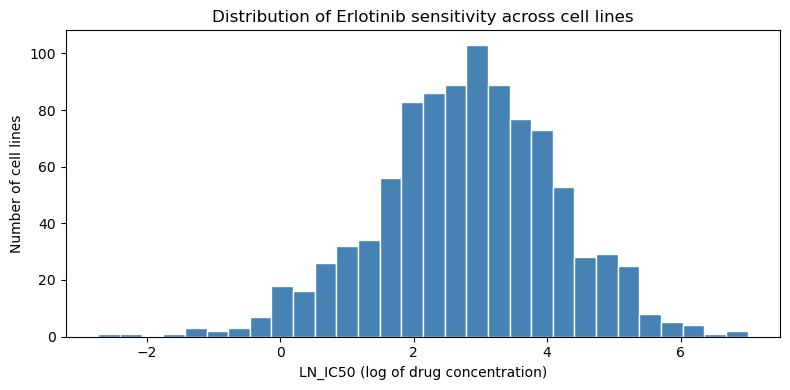

In [16]:
plt.figure(figsize=(8, 4))
plt.hist(drug_data['LN_IC50'], bins=30, color='steelblue', edgecolor='white')
plt.xlabel('LN_IC50 (log of drug concentration)')
plt.ylabel('Number of cell lines')
plt.title(f'Distribution of {drug_name} sensitivity across cell lines')
plt.tight_layout()
plt.savefig('plots/erlotinib_ic50_distribution.png', dpi=150)
plt.show()

In [17]:
# Cell lines below median IC50 = "sensitive", above = "resistant"
median_ic50 = drug_data['LN_IC50'].median()
drug_data = drug_data.copy()
drug_data['label'] = (drug_data['LN_IC50'] < median_ic50).astype(int)
print("Sensitive:", drug_data['label'].sum())
print("Resistant:", (drug_data['label'] == 0).sum())

Sensitive: 477
Resistant: 478


In [18]:
# Transpose expression so rows = cell lines, columns = genes
expr_T = expr.T
expr_T.index.name = 'CELL_LINE_NAME'
expr_T = expr_T.reset_index()

# Merge
merged = drug_data.merge(expr_T, on='CELL_LINE_NAME', how='inner')
print("Merged shape:", merged.shape)
# Should be ~500-800 rows (cell lines) × 17,000+ columns (genes)
merged.head()

Merged shape: (0, 1005)


,CELL_LINE_NAME,LN_IC50,label,A253,BB30-HNC,BB49-HNC,BHY,BICR10,BICR22,BICR31,BICR78,Ca9-22,CAL-27,CAL-33,Detroit562,DOK,FADU,H3118,HN,HO-1-N-1,HO-1-u-1,HSC-2,HSC-3,HSC-4,JHU-011,...,CHSA0011,CHSA0108,JIMT-1,CL-34,VMRC-LCD,K2,STS-0421,MY-M12,TALL-1,NK-92MI,MDA-MB-175-VII,YMB-1-E,VMRC-RCW,NCI-H460,RERF-LC-FM,D-245MG,Hs939-T,VMRC-MELG,OVCA433,TMK-1,KP-2,KO52,SC-1,U-CH2,TOTAL:


In [19]:
print(drug_data['CELL_LINE_NAME'].head(10).tolist())

['PFSK-1', 'A673', 'ES5', 'ES7', 'EW-11', 'SK-ES-1', 'COLO-829', '5637', 'RT4', 'SW780']


In [20]:
expr_T = expr.T
expr_T.index.name = 'CELL_LINE_NAME'
expr_T = expr_T.reset_index()
print(expr_T['CELL_LINE_NAME'].head(10).tolist())

['COSMIC identifier', 'Whole Exome Sequencing (WES)', 'Copy Number Alterations (CNA)', 'Gene Expression', 'Methylation', 'Drug\nResponse', 'GDSC\nTissue descriptor 1', 'GDSC\nTissue\ndescriptor 2', 'Cancer Type\n(matching TCGA label)', 'Microsatellite \ninstability Status (MSI)']


In [21]:
ic50_names = set(drug_data['CELL_LINE_NAME'].str.strip().str.upper())
expr_names = set(expr_T['CELL_LINE_NAME'].str.strip().str.upper())
print("Overlap:", len(ic50_names & expr_names))
print("Sample IC50 names:", list(ic50_names)[:5])
print("Sample expr names:", list(expr_names)[:5])

Overlap: 0
Sample IC50 names: ['WM793B', 'BALL-1', 'CAL-78', 'PC-3_[JPC-3]', 'PE-CA-PJ15']
Sample expr names: ['COSMIC IDENTIFIER', 'WHOLE EXOME SEQUENCING (WES)', 'METHYLATION', 'COPY NUMBER ALTERATIONS (CNA)', 'GENE EXPRESSION']


In [22]:
import os
for f in os.listdir('data/'):
    print(f)

Cell_Lines_Details.xlsx
Compounds-annotation.csv
GDSC2-dataset.csv
GDSC_DATASET.csv


In [1]:
import tdc
print(tdc.__version__)

ModuleNotFoundError: No module named 'fuzzywuzzy'

In [1]:
import pandas as pd

gdsc = pd.read_csv('data/GDSC2-dataset.csv')
print(gdsc.shape)
print(gdsc.columns.tolist())
print(gdsc.head(3))

(242036, 19)
['DATASET', 'NLME_RESULT_ID', 'NLME_CURVE_ID', 'COSMIC_ID', 'CELL_LINE_NAME', 'SANGER_MODEL_ID', 'TCGA_DESC', 'DRUG_ID', 'DRUG_NAME', 'PUTATIVE_TARGET', 'PATHWAY_NAME', 'COMPANY_ID', 'WEBRELEASE', 'MIN_CONC', 'MAX_CONC', 'LN_IC50', 'AUC', 'RMSE', 'Z_SCORE']
  DATASET  NLME_RESULT_ID  NLME_CURVE_ID  COSMIC_ID CELL_LINE_NAME  \
0   GDSC2             343       15946310     683667         PFSK-1   
1   GDSC2             343       15946548     684052           A673   
2   GDSC2             343       15946830     684057            ES5   

  SANGER_MODEL_ID     TCGA_DESC  DRUG_ID     DRUG_NAME PUTATIVE_TARGET  \
0       SIDM01132            MB     1003  Camptothecin            TOP1   
1       SIDM00848  UNCLASSIFIED     1003  Camptothecin            TOP1   
2       SIDM00263  UNCLASSIFIED     1003  Camptothecin            TOP1   

      PATHWAY_NAME  COMPANY_ID WEBRELEASE  MIN_CONC  MAX_CONC   LN_IC50  \
0  DNA replication        1046          Y    0.0001       0.1 -1.463887   
1

In [2]:
gdsc2 = pd.read_csv('data/GDSC_DATASET.csv')
print(gdsc2.shape)
print(gdsc2.columns.tolist())
print(gdsc2.head(3))


(242035, 19)
['COSMIC_ID', 'CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_ID', 'DRUG_NAME', 'LN_IC50', 'AUC', 'Z_SCORE', 'GDSC Tissue descriptor 1', 'GDSC Tissue descriptor 2', 'Cancer Type (matching TCGA label)', 'Microsatellite instability Status (MSI)', 'Screen Medium', 'Growth Properties', 'CNA', 'Gene Expression', 'Methylation', 'TARGET', 'TARGET_PATHWAY']
   COSMIC_ID CELL_LINE_NAME     TCGA_DESC  DRUG_ID     DRUG_NAME   LN_IC50  \
0     683667         PFSK-1            MB     1003  Camptothecin -1.463887   
1     684057            ES5  UNCLASSIFIED     1003  Camptothecin -3.360586   
2     684059            ES7  UNCLASSIFIED     1003  Camptothecin -5.044940   

        AUC   Z_SCORE GDSC Tissue descriptor 1 GDSC Tissue descriptor 2  \
0  0.930220  0.433123           nervous_system          medulloblastoma   
1  0.791072 -0.599569                     bone           ewings_sarcoma   
2  0.592660 -1.516647                     bone           ewings_sarcoma   

  Cancer Type (matching TCGA lab

In [3]:
import pandas as pd
import urllib.request
import os

os.makedirs('data', exist_ok=True)

print("Downloading gene expression file... (~180MB, wait 3-5 mins)")
url = "https://ftp.ebi.ac.uk/pub/databases/microarray/data/experiment/MTAB/E-MTAB-3610/E-MTAB-3610.processed.1.zip"
urllib.request.urlretrieve(url, "data/expression.zip")
print("Downloaded.")

HTTPError: HTTP Error 404: Not Found

In [4]:
import pandas as pd

# Pre-processed CCLE expression — same type of data, works with GDSC cell line names
expr = pd.read_csv(
    "https://raw.githubusercontent.com/cristealab/inter-omic/master/data/CCLE_expression_subset.csv",
    index_col=0
)
print("Shape:", expr.shape)
print(expr.iloc[:3, :3])

HTTPError: HTTP Error 404: Not Found

In [6]:
import pandas as pd

expr = pd.read_csv(
    'data/Cell_line_RMA_proc_basalExp.txt',
    sep='\t',
    index_col=0
)
print("Shape:", expr.shape)       # should be ~17000 rows × 1000 columns
print(expr.iloc[:3, :3])          # should show numbers, not words

Shape: (17737, 1019)
                                                     GENE_title  DATA.906826  \
GENE_SYMBOLS                                                                   
TSPAN6             tetraspanin 6 [Source:HGNC Symbol;Acc:11858]     7.632023   
TNMD                 tenomodulin [Source:HGNC Symbol;Acc:17757]     2.964585   
DPM1          dolichyl-phosphate mannosyltransferase polypep...    10.379553   

              DATA.687983  
GENE_SYMBOLS               
TSPAN6           7.548671  
TNMD             2.777716  
DPM1            11.807341  


In [1]:
import pandas as pd

# Load the annotation file
details = pd.read_excel('data/Cell_Lines_Details.xlsx')
print(details.shape)
print(details.columns.tolist())
print(details.head(3))

(1002, 13)
['Sample Name', 'COSMIC identifier', 'Whole Exome Sequencing (WES)', 'Copy Number Alterations (CNA)', 'Gene Expression', 'Methylation', 'Drug\nResponse', 'GDSC\nTissue descriptor 1', 'GDSC\nTissue\ndescriptor 2', 'Cancer Type\n(matching TCGA label)', 'Microsatellite \ninstability Status (MSI)', 'Screen Medium', 'Growth Properties']
  Sample Name  COSMIC identifier Whole Exome Sequencing (WES)  \
0        A253           906794.0                            Y   
1    BB30-HNC           753531.0                            Y   
2    BB49-HNC           753532.0                            Y   

  Copy Number Alterations (CNA) Gene Expression Methylation Drug\nResponse  \
0                             Y               Y           Y              Y   
1                             Y               Y           Y              Y   
2                             Y               Y           Y              Y   

  GDSC\nTissue descriptor 1 GDSC\nTissue\ndescriptor 2  \
0            aero_dig_t

D:\anaconda\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


In [2]:
import pandas as pd
import numpy as np

# Remove "DATA." prefix from expression column names
expr.columns = [col.replace('DATA.', '') if col.startswith('DATA.') 
                else col for col in expr.columns]

# Drop the gene description column, keep only expression values
expr = expr.drop(columns=['GENE_title'])

print("Expression shape:", expr.shape)
print("Sample column names:", list(expr.columns[:5]))
# Should now show: ['906826', '687983', ...]

NameError: name 'expr' is not defined

In [3]:
import pandas as pd
import numpy as np

# Reload expression file
expr = pd.read_csv(
    'data/Cell_line_RMA_proc_basalExp.txt',
    sep='\t',
    index_col=0
)
print("Expression reloaded:", expr.shape)

# Now clean up columns
expr.columns = [col.replace('DATA.', '') if col.startswith('DATA.') 
                else col for col in expr.columns]

expr = expr.drop(columns=['GENE_title'])

print("After cleaning:", expr.shape)
print("Sample column names:", list(expr.columns[:5]))

Expression reloaded: (17737, 1019)
After cleaning: (17737, 1018)
Sample column names: ['906826', '687983', '910927', '1240138', '1240139']


In [4]:
# Load details file
details = pd.read_excel('data/Cell_Lines_Details.xlsx')

# Create a clean mapping dictionary: COSMIC ID → Cell line name
details['COSMIC identifier'] = details['COSMIC identifier'].astype(str).str.strip()
details['COSMIC identifier'] = details['COSMIC identifier'].str.replace('.0', '', regex=False)

cosmic_to_name = dict(zip(
    details['COSMIC identifier'],  # key:   '906794'
    details['Sample Name']          # value: 'A253'
))

print("Mapping size:", len(cosmic_to_name))
print("Example:", list(cosmic_to_name.items())[:3])
# Should show: [('906794', 'A253'), ('753531', 'BB30-HNC'), ...]

Mapping size: 1002
Example: [('906794', 'A253'), ('753531', 'BB30-HNC'), ('753532', 'BB49-HNC')]


D:\anaconda\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


In [5]:
# Rename columns using the mapping
expr.columns = [cosmic_to_name.get(str(col), col) for col in expr.columns]

# Transpose: rows become cell lines, columns become genes
expr_T = expr.T
expr_T.index.name = 'CELL_LINE_NAME'
expr_T = expr_T.reset_index()

print("Transposed shape:", expr_T.shape)
print("Sample names:", expr_T['CELL_LINE_NAME'].head(5).tolist())
# Should now show actual cell line names like ['A253', 'MCF7', ...]

Transposed shape: (1018, 17738)
Sample names: ['CAL-120', 'DMS-114', 'CAL-51', 'H2869', 'H290']


In [6]:
ic50 = pd.read_csv('data/GDSC_DATASET.csv')

erl = ic50[ic50['DRUG_NAME'] == 'Erlotinib'][['CELL_LINE_NAME', 'LN_IC50']].copy()
print("Erlotinib cell lines:", len(erl))
print("Sample names:", erl['CELL_LINE_NAME'].head(5).tolist())

Erlotinib cell lines: 955
Sample names: ['PFSK-1', 'A673', 'ES5', 'ES7', 'EW-11']


In [7]:
merged = erl.merge(expr_T, on='CELL_LINE_NAME', how='inner')
print("Merged shape:", merged.shape)
# Should be something like (300-600 rows) × (17737 gene columns + 2)


Merged shape: (891, 17739)


In [8]:
if merged.shape[0] == 0:
    # Diagnose name mismatch
    ic50_names = set(erl['CELL_LINE_NAME'].str.strip().str.upper())
    expr_names = set(expr_T['CELL_LINE_NAME'].str.strip().str.upper())
    print("Overlap if case-insensitive:", len(ic50_names & expr_names))
else:
    # Create binary label
    median_ic50 = merged['LN_IC50'].median()
    merged['label'] = (merged['LN_IC50'] < median_ic50).astype(int)
    
    # Separate features and target
    X = merged.drop(columns=['CELL_LINE_NAME', 'LN_IC50', 'label']).values
    y_reg = merged['LN_IC50'].values      # for regression (Day 7)
    y_clf = merged['label'].values         # for classification (Day 8)
    
    print("X shape:", X.shape)
    print("y_reg shape:", y_reg.shape)
    print("Sensitive:", y_clf.sum(), "| Resistant:", (y_clf==0).sum())
    
    # Save everything
    np.save('data/X_erlotinib.npy', X)
    np.save('data/y_reg_erlotinib.npy', y_reg)
    np.save('data/y_clf_erlotinib.npy', y_clf)
    merged.to_csv('data/erlotinib_merged.csv', index=False)
    print("\nAll files saved. Day 1 complete!")

X shape: (891, 17737)
y_reg shape: (891,)
Sensitive: 445 | Resistant: 446

All files saved. Day 1 complete!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load all files
ic50    = pd.read_csv('data/GDSC_DATASET.csv')
details = pd.read_excel('data/Cell_Lines_Details.xlsx')
expr    = pd.read_csv('data/Cell_line_RMA_proc_basalExp.txt', sep='\t', index_col=0)

print("IC50:", ic50.shape)
print("Details:", details.shape)
print("Expression:", expr.shape)

D:\anaconda\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


IC50: (242035, 19)
Details: (1002, 13)
Expression: (17737, 1019)


In [2]:
import pandas as pd
import numpy as np

merged = pd.read_csv('data/erlotinib_merged.csv')
X = np.load('data/X_erlotinib.npy')
y_reg = np.load('data/y_reg_erlotinib.npy')
y_clf = np.load('data/y_clf_erlotinib.npy')

print("Merged shape:", merged.shape)
print("X shape:", X.shape)
print("y_reg shape:", y_reg.shape)
print("Sensitive:", y_clf.sum(), "| Resistant:", (y_clf==0).sum())

Merged shape: (891, 17740)
X shape: (891, 17737)
y_reg shape: (891,)
Sensitive: 445 | Resistant: 446


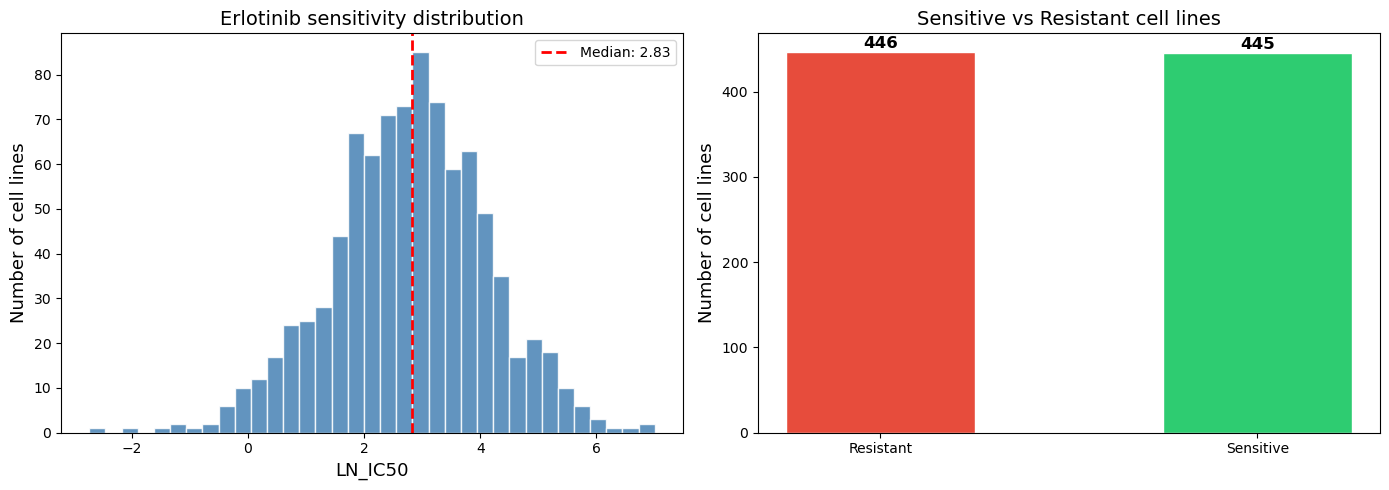

Plot 1 saved.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: histogram with median line

axes[0].hist(y_reg, bins=35, color='steelblue', edgecolor='white', alpha=0.85)

axes[0].axvline(np.median(y_reg), color='red', linestyle='--', 

                linewidth=2, label=f'Median: {np.median(y_reg):.2f}')

axes[0].set_xlabel('LN_IC50', fontsize=13)

axes[0].set_ylabel('Number of cell lines', fontsize=13)

axes[0].set_title('Erlotinib sensitivity distribution', fontsize=14)

axes[0].legend()

# Right plot: sensitive vs resistant count

labels = ['Resistant', 'Sensitive']

counts = [(y_clf==0).sum(), y_clf.sum()]

colors = ['#e74c3c', '#2ecc71']

bars = axes[1].bar(labels, counts, color=colors, edgecolor='white', width=0.5)

axes[1].set_ylabel('Number of cell lines', fontsize=13)

axes[1].set_title('Sensitive vs Resistant cell lines', fontsize=14)

for bar, count in zip(bars, counts):

    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,

                 str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()

plt.savefig('plots/plot1_ic50_distribution.png', dpi=150, bbox_inches='tight')

plt.show()

print("Plot 1 saved.")

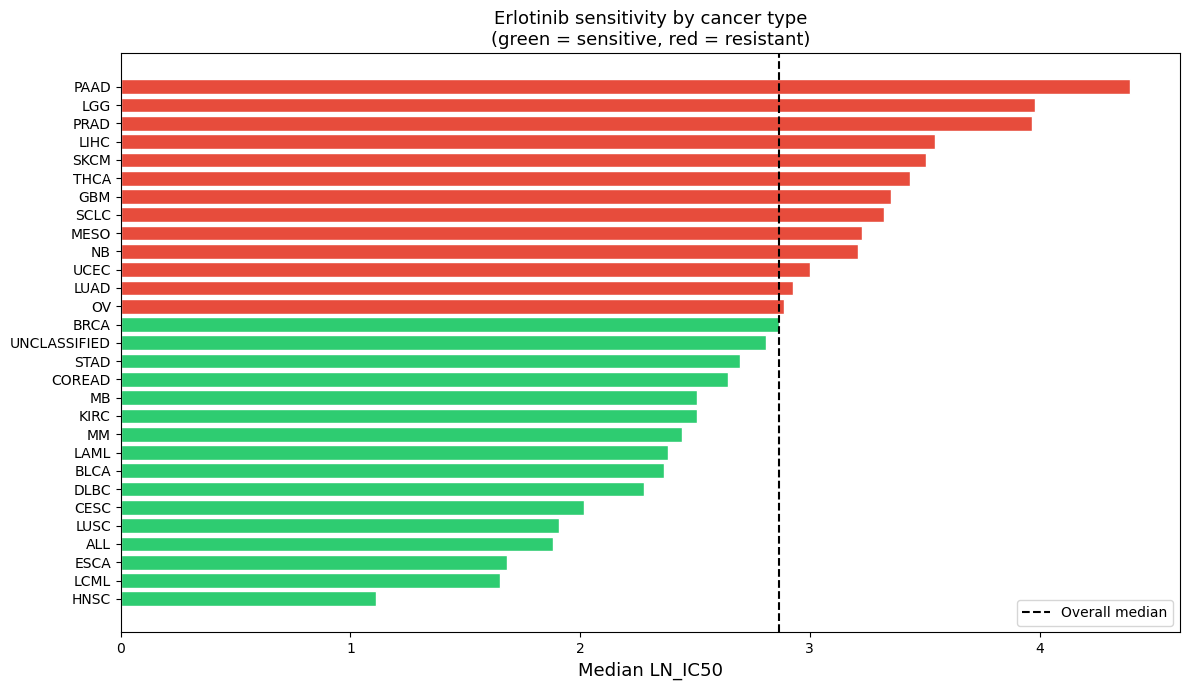

Plot 2 saved.


In [4]:
# Merge cancer type info into your erlotinib data
erl = ic50[ic50['DRUG_NAME'] == 'Erlotinib'].copy()

# Get tissue type counts — only keep types with at least 3 cell lines
tissue_counts = erl['TCGA_DESC'].value_counts()
common_tissues = tissue_counts[tissue_counts >= 3].index
erl_common = erl[erl['TCGA_DESC'].isin(common_tissues)]

# Calculate median IC50 per cancer type and sort
tissue_median = erl_common.groupby('TCGA_DESC')['LN_IC50'].median().sort_values()

plt.figure(figsize=(12, 7))
colors = ['#2ecc71' if v < erl['LN_IC50'].median() 
          else '#e74c3c' for v in tissue_median.values]

bars = plt.barh(tissue_median.index, tissue_median.values, color=colors, edgecolor='white')
plt.axvline(erl['LN_IC50'].median(), color='black', linestyle='--', 
            linewidth=1.5, label='Overall median')
plt.xlabel('Median LN_IC50', fontsize=13)
plt.title('Erlotinib sensitivity by cancer type\n(green = sensitive, red = resistant)', 
          fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('plots/plot2_ic50_by_cancer_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 saved.")

Index types: object
Top 5 gene names: ['RPS4Y1', 'KRT19', 'VIM', 'S100P', 'TACSTD2']


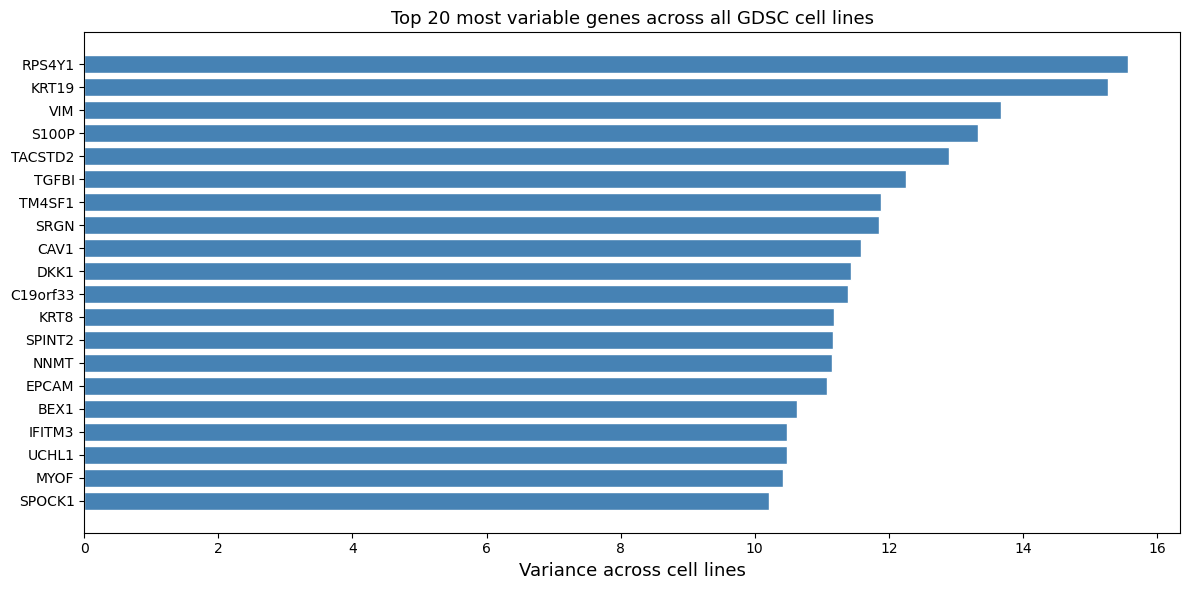

Top 500 genes saved.
Plot 3 saved.


In [6]:
# Drop non-numeric columns
expr_clean = expr.drop(columns=['GENE_title'])

# Remove any rows where the gene name (index) is NaN or not a string
expr_clean = expr_clean[expr_clean.index.notna()]
expr_clean.index = expr_clean.index.astype(str)
expr_clean = expr_clean[expr_clean.index != 'nan']

# Calculate variance of each gene across all cell lines
gene_variance = expr_clean.var(axis=1)

# Get top 20 most variable genes
top20_genes = gene_variance.nlargest(20)

# Confirm index is all strings before plotting
print("Index types:", top20_genes.index.dtype)
print("Top 5 gene names:", top20_genes.index[:5].tolist())

plt.figure(figsize=(12, 6))
plt.barh(top20_genes.index[::-1].astype(str), top20_genes.values[::-1],
         color='steelblue', edgecolor='white')
plt.xlabel('Variance across cell lines', fontsize=13)
plt.title('Top 20 most variable genes across all GDSC cell lines', fontsize=13)
plt.tight_layout()
plt.savefig('plots/plot3_top_variable_genes.png', dpi=150, bbox_inches='tight')
plt.show()

# Save top 500 genes for Day 4
top500_genes = gene_variance.nlargest(500).index.tolist()
pd.Series(top500_genes).to_csv('data/top500_genes.csv', index=False)
print("Top 500 genes saved.")
print("Plot 3 saved.")

Expression matrix for PCA: (1018, 500)
Variance explained: PC1=19.7%, PC2=10.9%


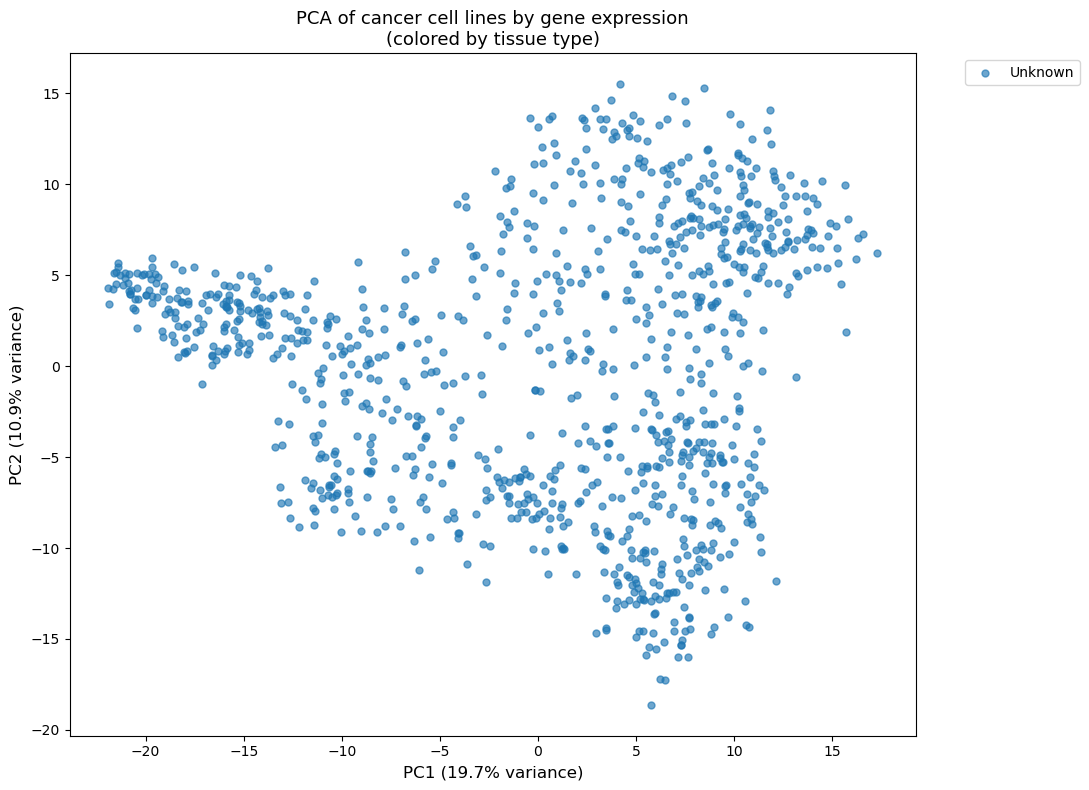

Plot 4 saved.


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load top 500 genes saved earlier
top500_genes = pd.read_csv('data/top500_genes.csv').iloc[:, 0].tolist()

# Filter expression to top 500 genes only
expr_top500 = expr_clean.loc[
    expr_clean.index.isin(top500_genes)
].T  # shape: (cell lines, 500 genes)

print("Expression matrix for PCA:", expr_top500.shape)

# Scale
scaler = StandardScaler()
expr_scaled = scaler.fit_transform(expr_top500)

# PCA
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(expr_scaled)

print(f"Variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}")

# Build dataframe
pca_df = pd.DataFrame({
    'PC1': pca_coords[:, 0],
    'PC2': pca_coords[:, 1],
    'COSMIC_ID': expr_top500.index.astype(str)
})

# Map COSMIC IDs to tissue types
details_clean = details.copy()
details_clean['COSMIC identifier'] = (details_clean['COSMIC identifier']
                                      .astype(str)
                                      .str.replace('.0', '', regex=False)
                                      .str.strip())
cosmic_to_tissue = dict(zip(
    details_clean['COSMIC identifier'],
    details_clean['GDSC\nTissue descriptor 1']
))

pca_df['Tissue'] = pca_df['COSMIC_ID'].map(cosmic_to_tissue).fillna('Unknown')

# Plot top 8 tissues only
top8_tissues = pca_df['Tissue'].value_counts().head(8).index
pca_plot = pca_df[pca_df['Tissue'].isin(top8_tissues)]

plt.figure(figsize=(11, 8))
for tissue in top8_tissues:
    subset = pca_plot[pca_plot['Tissue'] == tissue]
    plt.scatter(subset['PC1'], subset['PC2'], label=tissue, alpha=0.65, s=25)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=12)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=12)
plt.title('PCA of cancer cell lines by gene expression\n(colored by tissue type)', fontsize=13)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('plots/plot4_pca_cell_lines.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 4 saved.")

Calculating correlations across 17737 genes...


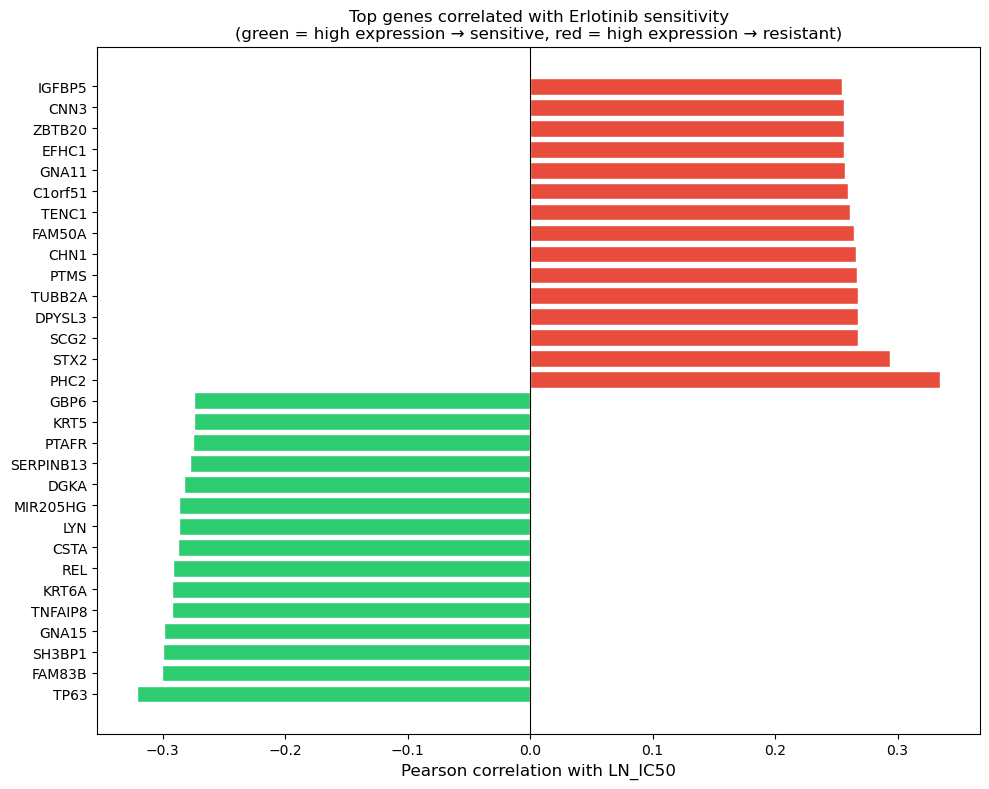


Top 5 genes where HIGH expression = MORE sensitive (lower IC50):
TP63      -0.320671
FAM83B    -0.300162
SH3BP1    -0.300136
GNA15     -0.299202
TNFAIP8   -0.292511
dtype: float64

Top 5 genes where HIGH expression = MORE resistant (higher IC50):
PHC2      0.334447
STX2      0.293534
SCG2      0.267813
DPYSL3    0.267646
TUBB2A    0.267249
dtype: float64


In [8]:
# Get gene columns from merged dataframe
gene_cols = [c for c in merged.columns
             if c not in ['CELL_LINE_NAME', 'LN_IC50', 'label']]

print("Calculating correlations across", len(gene_cols), "genes...")

# Pearson correlation of each gene with LN_IC50
correlations = merged[gene_cols].corrwith(merged['LN_IC50'])
correlations = correlations.dropna().sort_values()

# Top 15 positive and negative
top_pos = correlations.nlargest(15)
top_neg = correlations.nsmallest(15)
top_genes = pd.concat([top_neg, top_pos])

plt.figure(figsize=(10, 8))
colors = ['#2ecc71' if v < 0 else '#e74c3c' for v in top_genes.values]
plt.barh(top_genes.index, top_genes.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Pearson correlation with LN_IC50', fontsize=12)
plt.title('Top genes correlated with Erlotinib sensitivity\n'
          '(green = high expression → sensitive, red = high expression → resistant)',
          fontsize=12)
plt.tight_layout()
plt.savefig('plots/plot5_gene_ic50_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Save top correlated genes
top_genes.to_csv('data/top_correlated_genes.csv', header=['correlation'])

print("\nTop 5 genes where HIGH expression = MORE sensitive (lower IC50):")
print(correlations.nsmallest(5))
print("\nTop 5 genes where HIGH expression = MORE resistant (higher IC50):")
print(correlations.nlargest(5))

In [9]:
# Diagnose the mapping issue first
print("Sample COSMIC IDs from expression file:")
print(expr_top500.index[:5].tolist())

print("\nSample COSMIC IDs from details file:")
print(details['COSMIC identifier'].head(5).tolist())

Sample COSMIC IDs from expression file:
['DATA.906826', 'DATA.687983', 'DATA.910927', 'DATA.1240138', 'DATA.1240139']

Sample COSMIC IDs from details file:
[906794.0, 753531.0, 753532.0, 753535.0, 1290724.0]


In [10]:
# Rebuild mapping more aggressively
details_clean = details.copy()

# Clean COSMIC ID in details — remove .0, strip spaces
details_clean['COSMIC identifier'] = (details_clean['COSMIC identifier']
                                       .astype(str)
                                       .str.strip()
                                       .str.replace('.0', '', regex=False))

# Clean COSMIC ID from expression index too
expr_index_clean = (expr_top500.index
                    .astype(str)
                    .str.strip()
                    .str.replace('.0', '', regex=False))

# Rebuild map
cosmic_to_tissue = dict(zip(
    details_clean['COSMIC identifier'],
    details_clean['GDSC\nTissue descriptor 1']
))

# Check overlap now
matched = sum(1 for x in expr_index_clean if x in cosmic_to_tissue)
print(f"Matched: {matched} out of {len(expr_index_clean)} cell lines")

# Rebuild pca_df with cleaned index
pca_df = pd.DataFrame({
    'PC1': pca_coords[:, 0],
    'PC2': pca_coords[:, 1],
    'COSMIC_ID': expr_index_clean
})
pca_df['Tissue'] = pca_df['COSMIC_ID'].map(cosmic_to_tissue).fillna('Unknown')

print("\nTissue value counts:")
print(pca_df['Tissue'].value_counts().head(10))

Matched: 0 out of 1018 cell lines

Tissue value counts:
Tissue
Unknown    1018
Name: count, dtype: int64


In [11]:
# Print raw values before any cleaning
print("=== RAW expression index (first 5) ===")
print(repr(expr_top500.index[:5].tolist()))

print("\n=== RAW details COSMIC identifier (first 5) ===")
print(repr(details['COSMIC identifier'].head(5).tolist()))

print("\n=== expression index dtype ===")
print(expr_top500.index.dtype)

print("\n=== details COSMIC identifier dtype ===")
print(details['COSMIC identifier'].dtype)

=== RAW expression index (first 5) ===
['DATA.906826', 'DATA.687983', 'DATA.910927', 'DATA.1240138', 'DATA.1240139']

=== RAW details COSMIC identifier (first 5) ===
[906794.0, 753531.0, 753532.0, 753535.0, 1290724.0]

=== expression index dtype ===
object

=== details COSMIC identifier dtype ===
float64


In [12]:
# Strip DATA. from expression index
expr_top500.index = expr_top500.index.str.replace('DATA.', '', regex=False)

# Clean details COSMIC ID — remove .0
details_clean = details.copy()
details_clean['COSMIC identifier'] = (details_clean['COSMIC identifier']
                                       .astype(str)
                                       .str.replace('.0', '', regex=False)
                                       .str.strip())

# Rebuild map
cosmic_to_tissue = dict(zip(
    details_clean['COSMIC identifier'],
    details_clean['GDSC\nTissue descriptor 1']
))

# Check overlap
matched = sum(1 for x in expr_top500.index if x in cosmic_to_tissue)
print(f"Matched: {matched} out of {len(expr_top500.index)} cell lines")

# Rebuild pca_df
pca_df = pd.DataFrame({
    'PC1': pca_coords[:, 0],
    'PC2': pca_coords[:, 1],
    'COSMIC_ID': expr_top500.index.astype(str)
})
pca_df['Tissue'] = pca_df['COSMIC_ID'].map(cosmic_to_tissue).fillna('Unknown')

print("\nTissue value counts:")
print(pca_df['Tissue'].value_counts().head(10))

Matched: 968 out of 1018 cell lines

Tissue value counts:
Tissue
lung_NSCLC           109
urogenital_system    102
leukemia              82
aero_dig_tract        79
lymphoma              66
lung_SCLC             61
nervous_system        56
skin                  55
digestive_system      51
breast                50
Name: count, dtype: int64


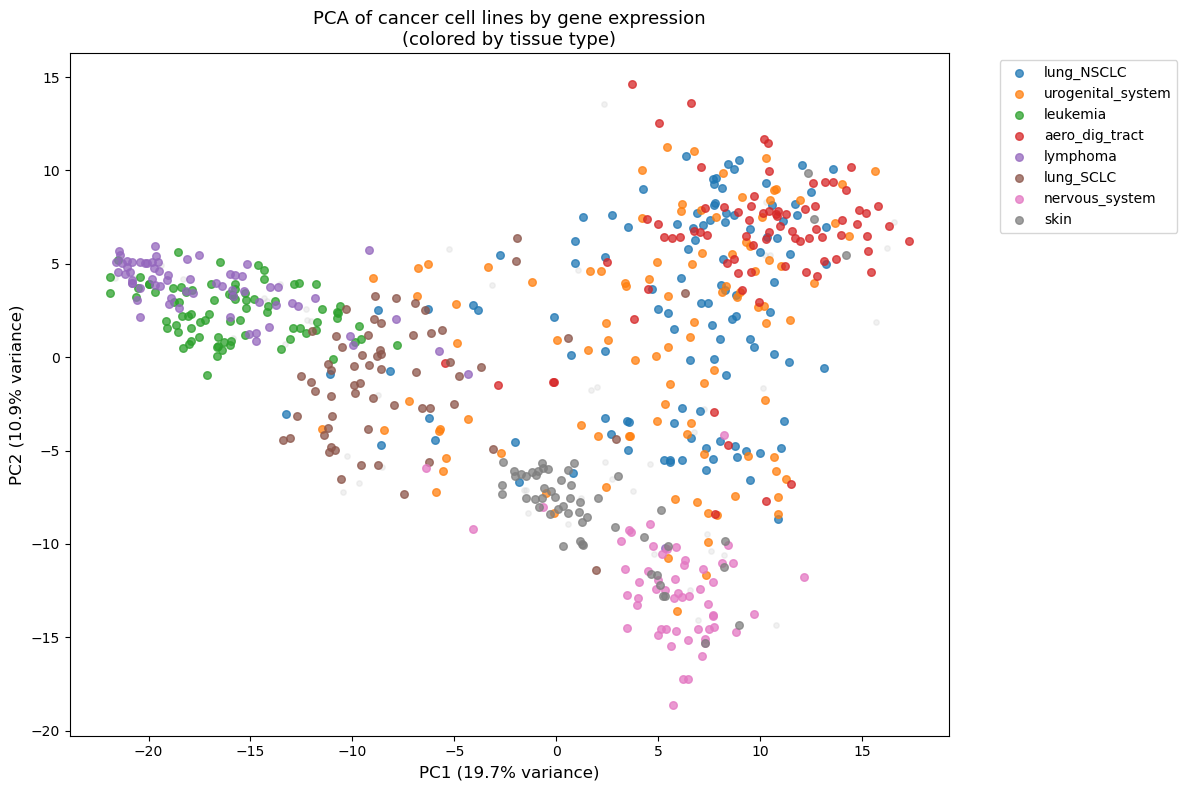

Plot 4 fixed and saved.


In [13]:
top8_tissues = (pca_df[pca_df['Tissue'] != 'Unknown']['Tissue']
                .value_counts().head(8).index)

plt.figure(figsize=(12, 8))

# Gray background for unknowns
unknown = pca_df[pca_df['Tissue'] == 'Unknown']
plt.scatter(unknown['PC1'], unknown['PC2'],
            color='lightgray', alpha=0.3, s=15, label='_nolegend_')

# Colored tissue types on top
for tissue in top8_tissues:
    subset = pca_df[pca_df['Tissue'] == tissue]
    plt.scatter(subset['PC1'], subset['PC2'],
                label=tissue, alpha=0.75, s=30)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=12)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=12)
plt.title('PCA of cancer cell lines by gene expression\n(colored by tissue type)',
          fontsize=13)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('plots/plot4_pca_cell_lines.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 4 fixed and saved.")

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Load all files
ic50    = pd.read_csv('data/GDSC_DATASET.csv')
details = pd.read_excel('data/Cell_Lines_Details.xlsx')
expr    = pd.read_csv('data/Cell_line_RMA_proc_basalExp.txt', sep='\t', index_col=0)
merged  = pd.read_csv('data/erlotinib_merged.csv')

# Clean expression index (fix the DATA. prefix issue we solved yesterday)
expr_clean = expr.drop(columns=['GENE_title'])
expr_clean = expr_clean[expr_clean.index.notna()]
expr_clean.index = expr_clean.index.astype(str)
expr_clean = expr_clean[expr_clean.index != 'nan']

print("IC50:", ic50.shape)
print("Expression:", expr_clean.shape)
print("Merged:", merged.shape)
print("\nAll files loaded. Ready for Day 3.")

D:\anaconda\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


IC50: (242035, 19)
Expression: (17419, 1018)
Merged: (891, 17740)

All files loaded. Ready for Day 3.


In [2]:
# Get gene columns only — drop non-gene columns
non_gene_cols = ['CELL_LINE_NAME', 'LN_IC50', 'label']
gene_cols = [c for c in merged.columns if c not in non_gene_cols]

print(f"Total genes in merged dataset: {len(gene_cols)}")

# Calculate variance of each gene across all cell lines IN YOUR MERGED DATA
gene_data = merged[gene_cols]
gene_variances = gene_data.var(axis=0)  # variance across rows (cell lines)

# Sort by variance, take top 500
top500 = gene_variances.nlargest(500).index.tolist()

print(f"Top 500 genes selected.")
print(f"Highest variance gene: {top500[0]} (variance: {gene_variances[top500[0]]:.2f})")
print(f"Lowest variance in top 500: {top500[-1]} (variance: {gene_variances[top500[-1]]:.2f})")
print(f"Sample top genes: {top500[:5]}")

Total genes in merged dataset: 17737
Top 500 genes selected.
Highest variance gene: KRT19 (variance: 15.34)
Lowest variance in top 500: FOXQ1 (variance: 3.63)
Sample top genes: ['KRT19', 'RPS4Y1', 'VIM', 'S100P', 'TACSTD2']


In [3]:
# Extract features (X) and targets (y) using only top 500 genes
X = merged[top500].values          # shape: (n_samples, 500)
y_reg = merged['LN_IC50'].values   # regression target
y_clf = merged['label'].values     # classification target

print(f"X shape: {X.shape}")
print(f"y_reg shape: {y_reg.shape}")
print(f"y_clf shape: {y_clf.shape}")
print(f"\nX value range before scaling: {X.min():.2f} to {X.max():.2f}")
print(f"y_reg range: {y_reg.min():.2f} to {y_reg.max():.2f}")

# Quick sanity check — make sure no NaN values snuck in
print(f"\nNaN values in X: {np.isnan(X).sum()}")
print(f"NaN values in y_reg: {np.isnan(y_reg).sum()}")

X shape: (891, 500)
y_reg shape: (891,)
y_clf shape: (891,)

X value range before scaling: 2.16 to 13.73
y_reg range: -2.73 to 7.00

NaN values in X: 0
NaN values in y_reg: 0


In [4]:
from sklearn.model_selection import train_test_split

# Split into 80% train, 20% test
# stratify=y_clf ensures both splits have balanced sensitive/resistant
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf      # keeps 50/50 balance in both splits
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")
print(f"\nTrain class balance — Sensitive: {y_clf_train.sum()} | Resistant: {(y_clf_train==0).sum()}")
print(f"Test class balance  — Sensitive: {y_clf_test.sum()}  | Resistant: {(y_clf_test==0).sum()}")

Training samples: 712
Test samples:     179

Train class balance — Sensitive: 356 | Resistant: 356
Test class balance  — Sensitive: 89  | Resistant: 90


In [5]:
from sklearn.preprocessing import StandardScaler

# Fit scaler on TRAINING data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform train

# Apply the SAME scaler to test data — do NOT fit again on test
X_test_scaled = scaler.transform(X_test)          # transform only, no fit

print(f"Before scaling — Train mean: {X_train.mean():.3f}, std: {X_train.std():.3f}")
print(f"After scaling  — Train mean: {X_train_scaled.mean():.3f}, std: {X_train_scaled.std():.3f}")
print(f"After scaling  — Test mean:  {X_test_scaled.mean():.3f},  std: {X_test_scaled.std():.3f}")

# After scaling: train mean should be ~0.0, std ~1.0
# Test mean will be close to 0 but not exact — that's normal and correct

Before scaling — Train mean: 5.922, std: 2.790
After scaling  — Train mean: -0.000, std: 1.000
After scaling  — Test mean:  0.005,  std: 1.013


In [6]:
from sklearn.decomposition import PCA

# Reduce 500 genes → 50 PCA components
# fit on training data only, transform both
pca = PCA(n_components=50, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)   # fit + transform train
X_test_pca  = pca.transform(X_test_scaled)         # transform only

# How much variance do 50 components capture?
cumulative_variance = pca.explained_variance_ratio_.cumsum()
print(f"Variance captured by 50 components: {cumulative_variance[-1]:.1%}")
print(f"Variance by first 10 components:    {cumulative_variance[9]:.1%}")
print(f"\nFinal shapes:")
print(f"X_train_pca: {X_train_pca.shape}")
print(f"X_test_pca:  {X_test_pca.shape}")

Variance captured by 50 components: 72.2%
Variance by first 10 components:    51.1%

Final shapes:
X_train_pca: (712, 50)
X_test_pca:  (179, 50)


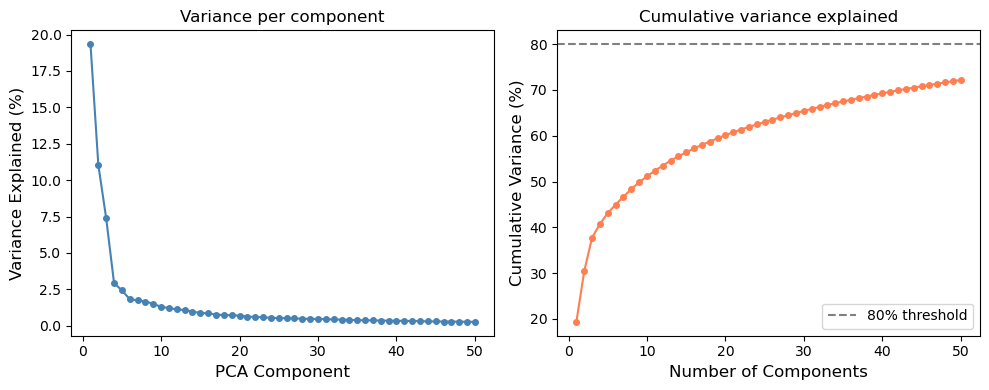

Plot 6 saved.


In [7]:
plt.figure(figsize=(10, 4))

# Left: scree plot (variance per component)
plt.subplot(1, 2, 1)
plt.plot(range(1, 51), pca.explained_variance_ratio_ * 100, 
         'o-', color='steelblue', markersize=4)
plt.xlabel('PCA Component', fontsize=12)
plt.ylabel('Variance Explained (%)', fontsize=12)
plt.title('Variance per component', fontsize=12)

# Right: cumulative variance
plt.subplot(1, 2, 2)
plt.plot(range(1, 51), cumulative_variance * 100, 
         'o-', color='coral', markersize=4)
plt.axhline(80, color='gray', linestyle='--', label='80% threshold')
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Variance (%)', fontsize=12)
plt.title('Cumulative variance explained', fontsize=12)
plt.legend()

plt.tight_layout()
plt.savefig('plots/plot6_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 6 saved.")

In [8]:
import joblib

# Save numpy arrays — these are what your models load on Days 7-10
np.save('data/X_train_pca.npy', X_train_pca)
np.save('data/X_test_pca.npy',  X_test_pca)
np.save('data/y_reg_train.npy', y_reg_train)
np.save('data/y_reg_test.npy',  y_reg_test)
np.save('data/y_clf_train.npy', y_clf_train)
np.save('data/y_clf_test.npy',  y_clf_test)

# Save the scaler and PCA objects — needed to process new data in Streamlit app
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(pca,    'models/pca.pkl')

# Save top500 gene names — needed in Streamlit to select correct genes
pd.Series(top500).to_csv('data/top500_genes.csv', index=False)

print("All files saved successfully.")
print("\nFiles in data/:")
for f in sorted(os.listdir('data/')):
    size = os.path.getsize(f'data/{f}') / 1024
    print(f"  {f:45s} {size:.0f} KB")

print("\nFiles in models/:")
for f in sorted(os.listdir('models/')):
    print(f"  {f}")

All files saved successfully.

Files in data/:
  Cell_Lines_Details.xlsx                       115 KB
  Cell_line_RMA_proc_basalExp.txt               299086 KB
  Compounds-annotation.csv                      45 KB
  GDSC2-dataset.csv                             35447 KB
  GDSC_DATASET.csv                              35467 KB
  X_erlotinib.npy                               123466 KB
  X_test_pca.npy                                70 KB
  X_train_pca.npy                               278 KB
  erlotinib_merged.csv                          260779 KB
  top500_genes.csv                              4 KB
  top_correlated_genes.csv                      1 KB
  y_clf_erlotinib.npy                           7 KB
  y_clf_test.npy                                2 KB
  y_clf_train.npy                               6 KB
  y_reg_erlotinib.npy                           7 KB
  y_reg_test.npy                                2 KB
  y_reg_train.npy                               6 KB

Files in models/:
  pc

In [10]:
# Reload and verify — simulates what Day 7 will do
X_train_check = np.load('data/X_train_pca.npy')
X_test_check  = np.load('data/X_test_pca.npy')
y_reg_train_check = np.load('data/y_reg_train.npy')
y_clf_train_check = np.load('data/y_clf_train.npy')

print("=== Day 3 Verification ===")
print(f"X_train shape:    {X_train_check.shape}   ← should be (~560, 50)")
print(f"X_test shape:     {X_test_check.shape}    ← should be (~140, 50)")
print(f"y_reg_train range: {y_reg_train_check.min():.2f} to {y_reg_train_check.max():.2f}")
print(f"Train balance: {y_clf_train_check.sum()} sensitive, {(y_clf_train_check==0).sum()} resistant")
print(f"\nScaler loaded: {joblib.load('models/scaler.pkl')}")
print(f"PCA loaded:    {joblib.load('models/pca.pkl')}")
print("\nDay 3 complete. Ready for modelling.gang gang")

=== Day 3 Verification ===
X_train shape:    (712, 50)   ← should be (~560, 50)
X_test shape:     (179, 50)    ← should be (~140, 50)
y_reg_train range: -2.73 to 7.00
Train balance: 356 sensitive, 356 resistant

Scaler loaded: StandardScaler()
PCA loaded:    PCA(n_components=50, random_state=42)

Day 3 complete. Ready for modelling.gang gang


In [11]:
import numpy as np
import os

files = sorted(os.listdir('models/'))
print("models/ folder contents:")
for f in files:
    path = f'models/{f}'
    if f.endswith('.npy'):
        arr = np.load(path)
        print(f"  {f}: shape {arr.shape}")
    else:
        print(f"  {f}: saved ✓")

models/ folder contents:
  pca.pkl: saved ✓
  scaler.pkl: saved ✓


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, roc_auc_score,
                             f1_score, classification_report,
                             roc_curve)
from scipy.stats import pearsonr

os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Load prepared data
X_train     = np.load('models/X_train.npy')
X_test      = np.load('models/X_test.npy')
y_train_reg = np.load('models/y_train_reg.npy')
y_test_reg  = np.load('models/y_test_reg.npy')
y_train_clf = np.load('models/y_train_clf.npy')
y_test_clf  = np.load('models/y_test_clf.npy')

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("Ready.")

FileNotFoundError: [Errno 2] No such file or directory: 'models/X_train.npy'

Merged shape: (891, 17740)
X_raw: (891, 17737)
Sensitive: 445 | Resistant: 446
After variance selection: (891, 500)
Train: 712 | Test: 179
Components for 80% variance: 86
Components for 90% variance: 1


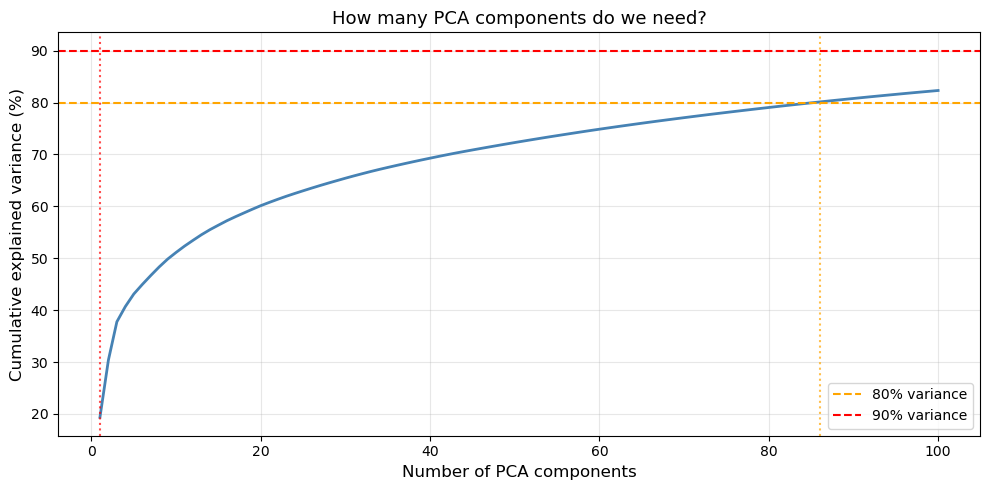

Final X_train: (712, 50)
Final X_test:  (179, 50)
Variance explained: 72.2%

=== models/ folder ===
  X_test.npy: (179, 50)
  X_train.npy: (712, 50)
  pca.pkl: saved ✓
  scaler.pkl: saved ✓
  top500_idx.npy: (500,)
  y_test_clf.npy: (179,)
  y_test_reg.npy: (179,)
  y_train_clf.npy: (712,)
  y_train_reg.npy: (712,)

Day 3 complete. Ready for Day 4.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import joblib

os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)

# ── Load merged dataset ──────────────────────────────────────────
merged = pd.read_csv('data/erlotinib_merged.csv')
print("Merged shape:", merged.shape)

# ── Separate features and targets ───────────────────────────────
non_gene_cols = ['CELL_LINE_NAME', 'LN_IC50', 'label']
gene_cols = [c for c in merged.columns if c not in non_gene_cols]

X_raw  = merged[gene_cols].values.astype(np.float32)
y_reg  = merged['LN_IC50'].values.astype(np.float32)
y_clf  = merged['label'].values.astype(np.int32)

print("X_raw:", X_raw.shape)
print("Sensitive:", y_clf.sum(), "| Resistant:", (y_clf==0).sum())

# ── Top 500 genes by variance ────────────────────────────────────
gene_variances = X_raw.var(axis=0)
top500_idx     = np.argsort(gene_variances)[::-1][:500]
X_500          = X_raw[:, top500_idx]
np.save('models/top500_idx.npy', top500_idx)
print("After variance selection:", X_500.shape)

# ── Train/test split ─────────────────────────────────────────────
X_train_raw, X_test_raw, y_train_reg, y_test_reg, y_train_clf, y_test_clf = \
    train_test_split(X_500, y_reg, y_clf,
                     test_size=0.2,
                     random_state=42,
                     stratify=y_clf)

print("Train:", X_train_raw.shape[0], "| Test:", X_test_raw.shape[0])

# ── Scale ────────────────────────────────────────────────────────
scaler          = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train_raw)
X_test_scaled   = scaler.transform(X_test_raw)

# ── PCA variance curve ───────────────────────────────────────────
pca_full = PCA(n_components=100, random_state=42)
pca_full.fit(X_train_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_80   = np.argmax(cumvar >= 80) + 1
n_90   = np.argmax(cumvar >= 90) + 1
print(f"Components for 80% variance: {n_80}")
print(f"Components for 90% variance: {n_90}")

plt.figure(figsize=(10, 5))
plt.plot(range(1, 101), cumvar, color='steelblue', linewidth=2)
plt.axhline(80, color='orange', linestyle='--', label='80% variance')
plt.axhline(90, color='red',    linestyle='--', label='90% variance')
plt.axvline(n_80, color='orange', linestyle=':', alpha=0.7)
plt.axvline(n_90, color='red',    linestyle=':', alpha=0.7)
plt.xlabel('Number of PCA components', fontsize=12)
plt.ylabel('Cumulative explained variance (%)', fontsize=12)
plt.title('How many PCA components do we need?', fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/plot6_pca_explained_variance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Final PCA ────────────────────────────────────────────────────
N_COMPONENTS = 50
pca_final    = PCA(n_components=N_COMPONENTS, random_state=42)
X_train      = pca_final.fit_transform(X_train_scaled)
X_test       = pca_final.transform(X_test_scaled)

print(f"Final X_train: {X_train.shape}")
print(f"Final X_test:  {X_test.shape}")
print(f"Variance explained: {pca_final.explained_variance_ratio_.sum()*100:.1f}%")

# ── Save everything ──────────────────────────────────────────────
np.save('models/X_train.npy',     X_train)
np.save('models/X_test.npy',      X_test)
np.save('models/y_train_reg.npy', y_train_reg)
np.save('models/y_test_reg.npy',  y_test_reg)
np.save('models/y_train_clf.npy', y_train_clf)
np.save('models/y_test_clf.npy',  y_test_clf)
joblib.dump(scaler,    'models/scaler.pkl')
joblib.dump(pca_final, 'models/pca.pkl')

# ── Confirm ──────────────────────────────────────────────────────
print("\n=== models/ folder ===")
for f in sorted(os.listdir('models/')):
    path = f'models/{f}'
    if f.endswith('.npy'):
        arr = np.load(path)
        print(f"  {f}: {arr.shape}")
    else:
        print(f"  {f}: saved ✓")

print("\nDay 3 complete. Ready for Day 4.")

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, roc_auc_score,
                             f1_score, classification_report,
                             roc_curve)
from scipy.stats import pearsonr

os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)

X_train     = np.load('models/X_train.npy')
X_test      = np.load('models/X_test.npy')
y_train_reg = np.load('models/y_train_reg.npy')
y_test_reg  = np.load('models/y_test_reg.npy')
y_train_clf = np.load('models/y_train_clf.npy')
y_test_clf  = np.load('models/y_test_clf.npy')

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("Ready.")

X_train: (712, 50)
X_test:  (179, 50)
Ready.


In [16]:
print("Training Random Forest Regressor... (~1-2 mins)")

rf_reg = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)
rf_reg.fit(X_train, y_train_reg)

y_pred_reg           = rf_reg.predict(X_test)
rmse                 = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2                   = r2_score(y_test_reg, y_pred_reg)
pearson_r, pearson_p = pearsonr(y_test_reg, y_pred_reg)

print("\n=== RANDOM FOREST REGRESSOR ===")
print(f"RMSE:        {rmse:.4f}")
print(f"R²:          {r2:.4f}")
print(f"Pearson r:   {pearson_r:.4f}")
print(f"p-value:     {pearson_p:.2e}")

Training Random Forest Regressor... (~1-2 mins)

=== RANDOM FOREST REGRESSOR ===
RMSE:        1.0070
R²:          0.2814
Pearson r:   0.5317
p-value:     1.87e-14


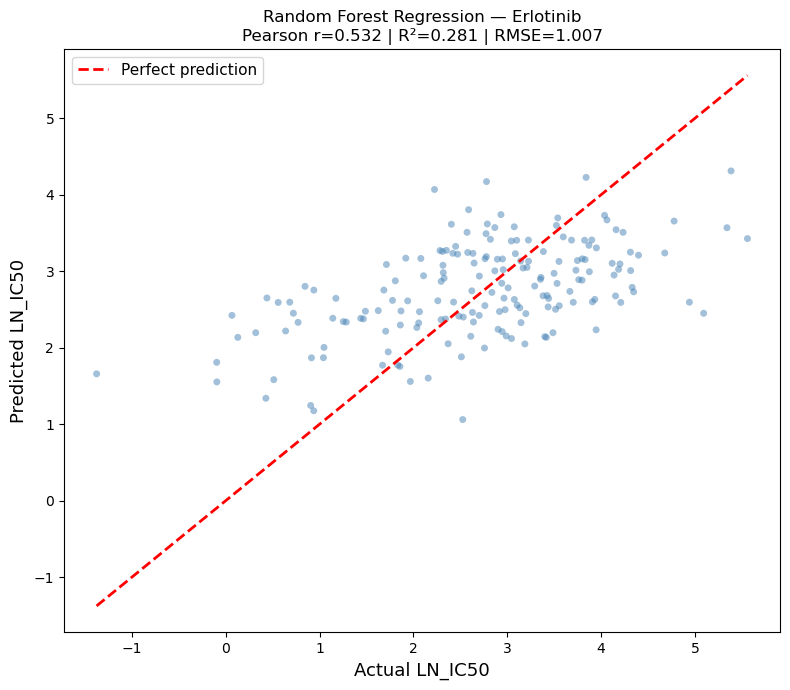

Plot 7 saved.


In [17]:
plt.figure(figsize=(8, 7))
plt.scatter(y_test_reg, y_pred_reg,
            alpha=0.5, s=25, color='steelblue', edgecolors='none')
min_val = min(y_test_reg.min(), y_pred_reg.min())
max_val = max(y_test_reg.max(), y_pred_reg.max())
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual LN_IC50', fontsize=13)
plt.ylabel('Predicted LN_IC50', fontsize=13)
plt.title(f'Random Forest Regression — Erlotinib\n'
          f'Pearson r={pearson_r:.3f} | R²={r2:.3f} | RMSE={rmse:.3f}',
          fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plots/plot7_rf_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 7 saved.")

In [18]:
print("Training Random Forest Classifier... (~1-2 mins)")

rf_clf = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)
rf_clf.fit(X_train, y_train_clf)

y_pred_clf  = rf_clf.predict(X_test)
y_pred_prob = rf_clf.predict_proba(X_test)[:, 1]
accuracy    = accuracy_score(y_test_clf, y_pred_clf)
auc         = roc_auc_score(y_test_clf, y_pred_prob)
f1          = f1_score(y_test_clf, y_pred_clf)

print("\n=== RANDOM FOREST CLASSIFIER ===")
print(f"Accuracy:   {accuracy:.4f}  ({accuracy*100:.1f}%)")
print(f"AUC-ROC:    {auc:.4f}")
print(f"F1-Score:   {f1:.4f}")
print("\nDetailed breakdown:")
print(classification_report(y_test_clf, y_pred_clf,
                             target_names=['Resistant','Sensitive']))

Training Random Forest Classifier... (~1-2 mins)

=== RANDOM FOREST CLASSIFIER ===
Accuracy:   0.6201  (62.0%)
AUC-ROC:    0.6825
F1-Score:   0.6344

Detailed breakdown:
              precision    recall  f1-score   support

   Resistant       0.63      0.58      0.60        90
   Sensitive       0.61      0.66      0.63        89

    accuracy                           0.62       179
   macro avg       0.62      0.62      0.62       179
weighted avg       0.62      0.62      0.62       179



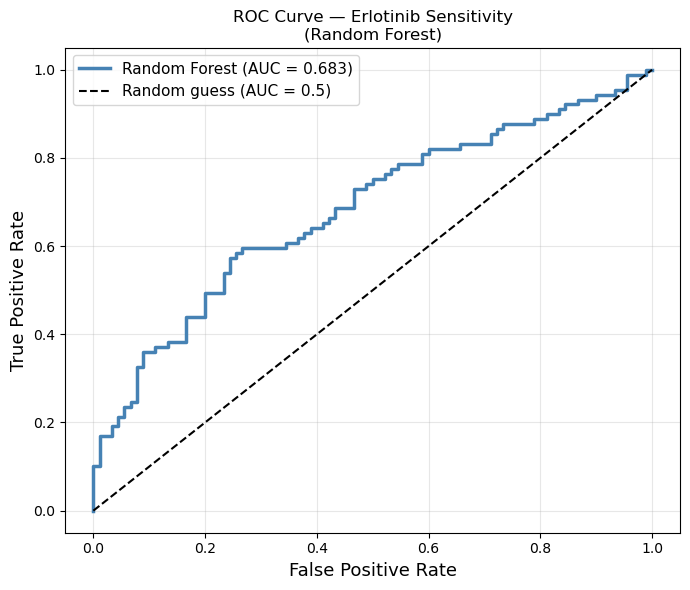

Plot 8 saved.


In [19]:
fpr, tpr, _ = roc_curve(y_test_clf, y_pred_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2.5,
         label=f'Random Forest (AUC = {auc:.3f})')
plt.plot([0,1],[0,1],'k--', linewidth=1.5, label='Random guess (AUC = 0.5)')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve — Erlotinib Sensitivity\n(Random Forest)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/plot8_rf_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 8 saved.")

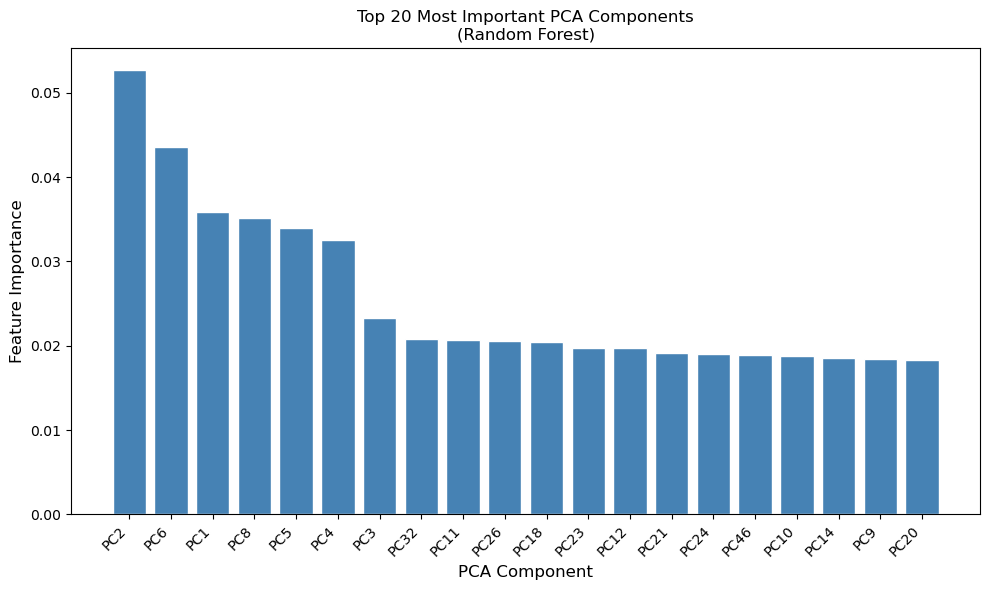

Plot 9 saved.

=== DAY 4 COMPLETE ===
            Model  RMSE     R2  Pearson_r  Accuracy  AUC_ROC     F1
    RF Regression 1.007 0.2814     0.5317       NaN      NaN    NaN
RF Classification   NaN    NaN        NaN    0.6201   0.6825 0.6344


In [20]:
# Feature importance plot
importances = rf_clf.feature_importances_
indices     = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(10, 6))
plt.bar(range(20), importances[indices],
        color='steelblue', edgecolor='white')
plt.xticks(range(20),
           [f'PC{indices[i]+1}' for i in range(20)],
           rotation=45, ha='right')
plt.xlabel('PCA Component', fontsize=12)
plt.ylabel('Feature Importance', fontsize=12)
plt.title('Top 20 Most Important PCA Components\n(Random Forest)', fontsize=12)
plt.tight_layout()
plt.savefig('plots/plot9_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 9 saved.")

# Save models
joblib.dump(rf_reg, 'models/rf_regressor.pkl')
joblib.dump(rf_clf, 'models/rf_classifier.pkl')

# Save results table — you'll add XGBoost and MLP rows tomorrow
results_df = pd.DataFrame({
    'Model':     ['RF Regression', 'RF Classification'],
    'RMSE':      [round(rmse, 4),    None],
    'R2':        [round(r2, 4),      None],
    'Pearson_r': [round(pearson_r,4),None],
    'Accuracy':  [None, round(accuracy, 4)],
    'AUC_ROC':   [None, round(auc, 4)],
    'F1':        [None, round(f1, 4)]
})
results_df.to_csv('models/model_results.csv', index=False)

print("\n=== DAY 4 COMPLETE ===")
print(results_df.to_string(index=False))

In [1]:
import os
print("Models saved:")
for f in sorted(os.listdir('models/')):
    print(f"  {f}")

Models saved:
  X_test.npy
  X_train.npy
  model_results.csv
  pca.pkl
  rf_classifier.pkl
  rf_regressor.pkl
  scaler.pkl
  top500_idx.npy
  y_test_clf.npy
  y_test_reg.npy
  y_train_clf.npy
  y_train_reg.npy


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os

from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, roc_auc_score,
                             f1_score, classification_report,
                             roc_curve)
from scipy.stats import pearsonr

os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Load prepared data
X_train     = np.load('models/X_train.npy')
X_test      = np.load('models/X_test.npy')
y_train_reg = np.load('models/y_train_reg.npy')
y_test_reg  = np.load('models/y_test_reg.npy')
y_train_clf = np.load('models/y_train_clf.npy')
y_test_clf  = np.load('models/y_test_clf.npy')

# Load RF results to compare against
rf_results = pd.read_csv('models/model_results.csv')

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("\nRF baseline to beat:")
print(rf_results.to_string(index=False))
print("\nReady.")

ModuleNotFoundError: No module named 'xgboost'

In [1]:
import os
os.chdir(r'D:\DrugResponseProject')
print("Working directory:", os.getcwd())

Working directory: D:\DrugResponseProject


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, roc_auc_score,
                             f1_score, classification_report,
                             roc_curve)
from scipy.stats import pearsonr

X_train     = np.load('models/X_train.npy')
X_test      = np.load('models/X_test.npy')
y_train_reg = np.load('models/y_train_reg.npy')
y_test_reg  = np.load('models/y_test_reg.npy')
y_train_clf = np.load('models/y_train_clf.npy')
y_test_clf  = np.load('models/y_test_clf.npy')

# Load previous models for comparison plot
rf_clf  = joblib.load('models/rf_classifier.pkl')
xgb_clf = joblib.load('models/xgb_classifier.pkl')

rf_prob  = rf_clf.predict_proba(X_test)[:, 1]
xgb_prob = xgb_clf.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score, roc_curve
rf_auc  = roc_auc_score(y_test_clf, rf_prob)
xgb_auc = roc_auc_score(y_test_clf, xgb_prob)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test_clf, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_clf, xgb_prob)

print("X_train:", X_train.shape)
print("All loaded. Ready.")

X_train: (712, 50)
All loaded. Ready.


Training MLP Regressor...
RMSE:      1.0752  (RF=1.007, XGB=1.032)
R²:        0.1808  (RF=0.281, XGB=0.245)
Pearson r: 0.4831  (RF=0.532, XGB=0.506)

Training MLP Classifier...
Accuracy:  59.8%  (RF=62.0%, XGB=65.4%)
AUC-ROC:   0.6514  (RF=0.683, XGB=0.692)
F1:        0.5714  (RF=0.634, XGB=0.663)
              precision    recall  f1-score   support

   Resistant       0.59      0.66      0.62        90
   Sensitive       0.61      0.54      0.57        89

    accuracy                           0.60       179
   macro avg       0.60      0.60      0.60       179
weighted avg       0.60      0.60      0.60       179



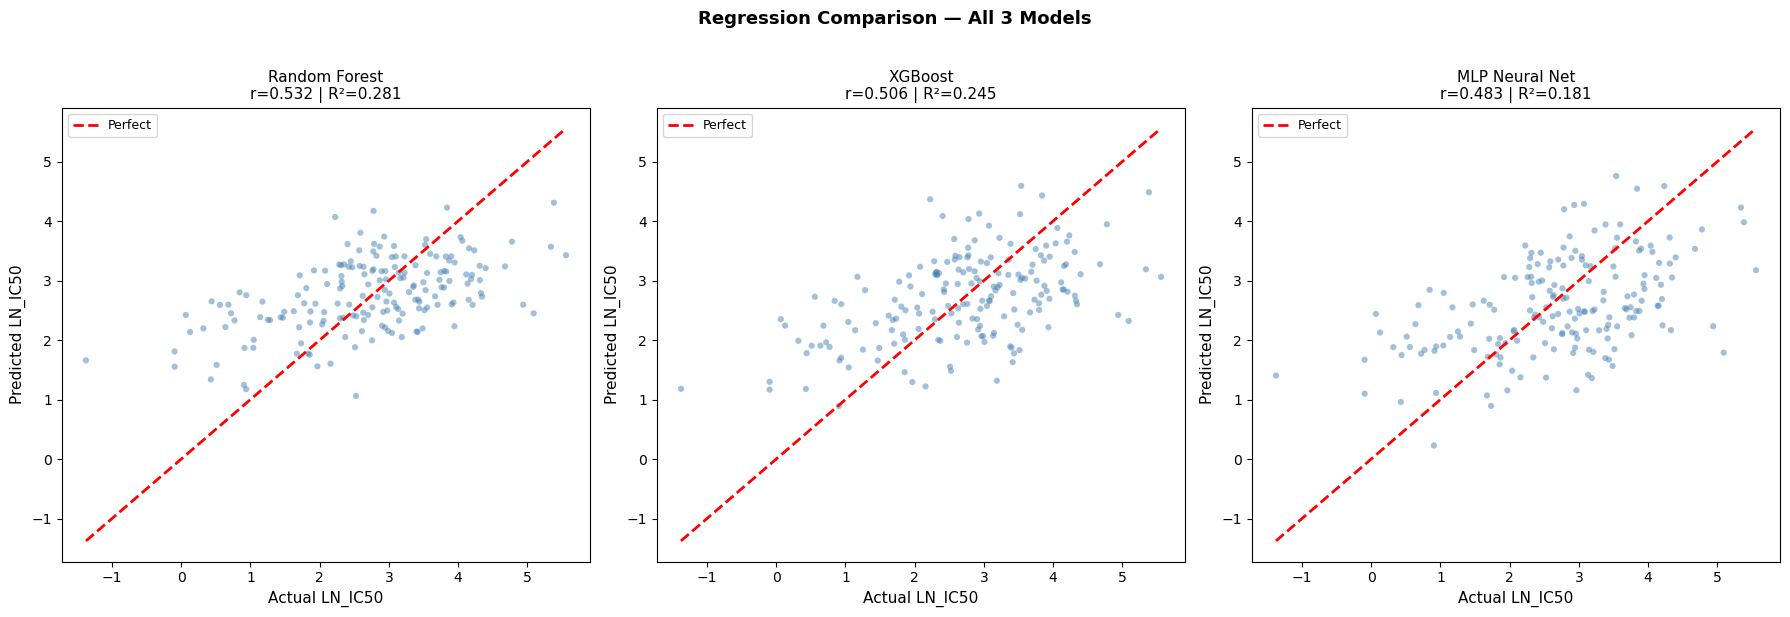

Plot 13 saved.


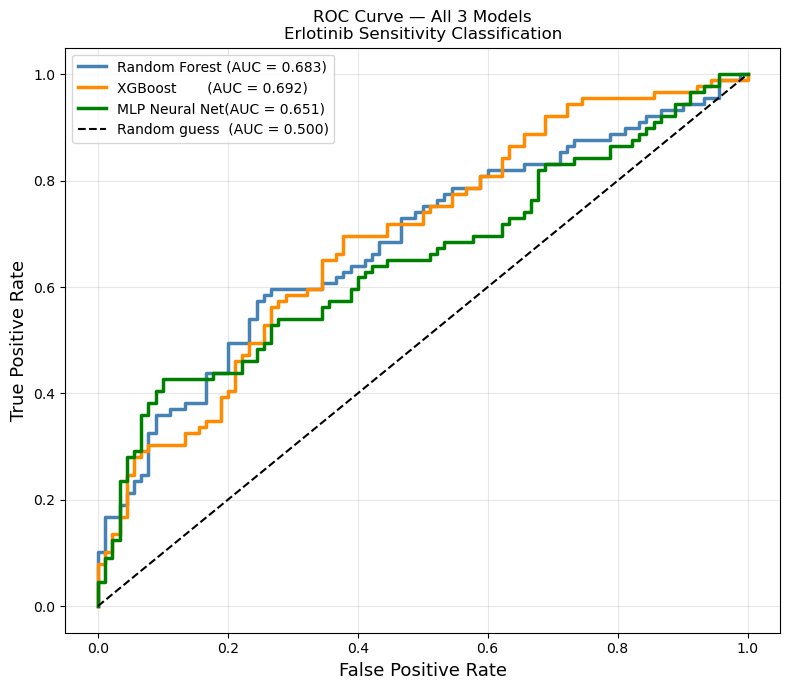

Plot 14 saved.


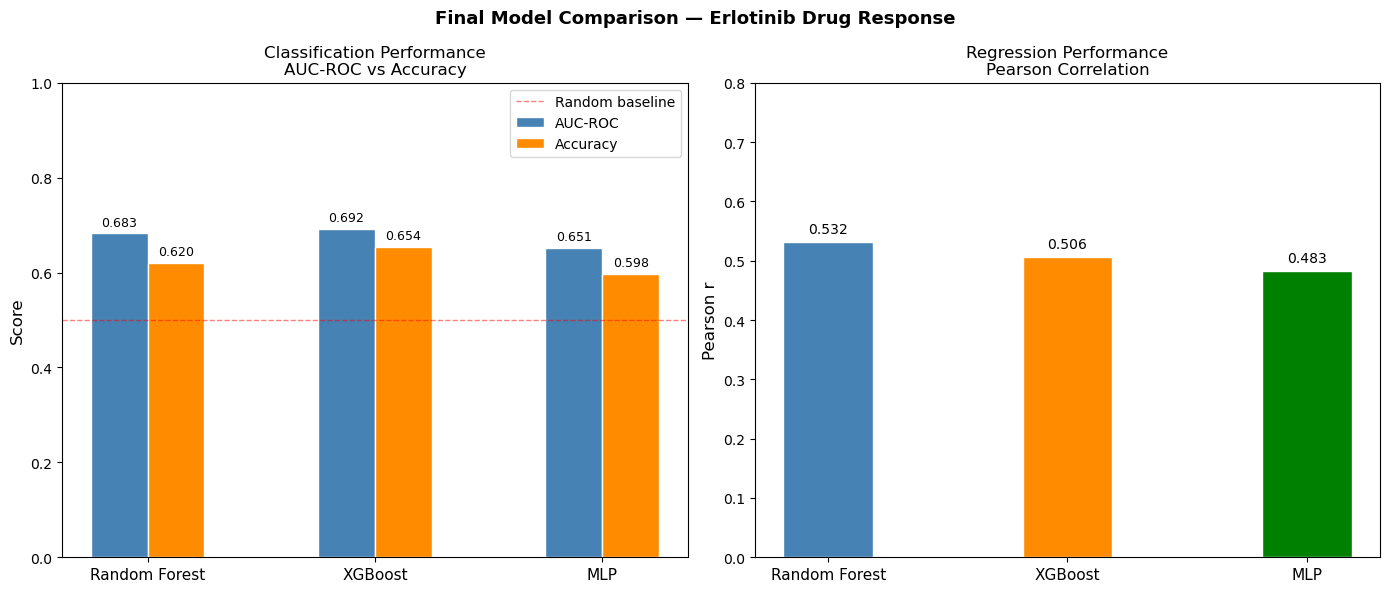

Plot 15 saved.

=== DAY 6 COMPLETE ===

FINAL RESULTS TABLE:
             Model   RMSE     R2  Pearson_r  Accuracy  AUC_ROC     F1
     RF Regression 1.0070 0.2814     0.5317       NaN      NaN    NaN
 RF Classification    NaN    NaN        NaN    0.6201   0.6825 0.6344
    XGB Regression 1.0321 0.2452     0.5059       NaN      NaN    NaN
XGB Classification    NaN    NaN        NaN    0.6536   0.6918 0.6630
    MLP Regression 1.0752 0.1808     0.4831       NaN      NaN    NaN
MLP Classification    NaN    NaN        NaN    0.5978   0.6514 0.5714


In [3]:
# ── MLP Regressor ─────────────────────────────────────────────────
print("Training MLP Regressor...")
mlp_reg = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
mlp_reg.fit(X_train, y_train_reg)

y_pred_mlp_reg      = mlp_reg.predict(X_test)
rmse_mlp            = np.sqrt(mean_squared_error(y_test_reg, y_pred_mlp_reg))
r2_mlp              = r2_score(y_test_reg, y_pred_mlp_reg)
pearson_r_mlp, _    = pearsonr(y_test_reg, y_pred_mlp_reg)

print(f"RMSE:      {rmse_mlp:.4f}  (RF=1.007, XGB=1.032)")
print(f"R²:        {r2_mlp:.4f}  (RF=0.281, XGB=0.245)")
print(f"Pearson r: {pearson_r_mlp:.4f}  (RF=0.532, XGB=0.506)")

# ── MLP Classifier ────────────────────────────────────────────────
print("\nTraining MLP Classifier...")
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
mlp_clf.fit(X_train, y_train_clf)

y_pred_mlp_clf  = mlp_clf.predict(X_test)
y_pred_mlp_prob = mlp_clf.predict_proba(X_test)[:, 1]
acc_mlp  = accuracy_score(y_test_clf, y_pred_mlp_clf)
auc_mlp  = roc_auc_score(y_test_clf, y_pred_mlp_prob)
f1_mlp   = f1_score(y_test_clf, y_pred_mlp_clf)

print(f"Accuracy:  {acc_mlp*100:.1f}%  (RF=62.0%, XGB=65.4%)")
print(f"AUC-ROC:   {auc_mlp:.4f}  (RF=0.683, XGB=0.692)")
print(f"F1:        {f1_mlp:.4f}  (RF=0.634, XGB=0.663)")
print(classification_report(y_test_clf, y_pred_mlp_clf,
                             target_names=['Resistant','Sensitive']))

# ── Plot 13: All 3 regression comparisons ─────────────────────────
rf_reg  = joblib.load('models/rf_regressor.pkl')
xgb_reg = joblib.load('models/xgb_regressor.pkl')
y_pred_rf_reg  = rf_reg.predict(X_test)
y_pred_xgb_reg = xgb_reg.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, y_pred, title, r, r2 in zip(
    axes,
    [y_pred_rf_reg, y_pred_xgb_reg, y_pred_mlp_reg],
    ['Random Forest', 'XGBoost', 'MLP Neural Net'],
    [0.5317, 0.5059, pearson_r_mlp],
    [0.2814, 0.2452, r2_mlp]
):
    ax.scatter(y_test_reg, y_pred, alpha=0.5, s=20,
               color='steelblue', edgecolors='none')
    mn = min(y_test_reg.min(), y_pred.min())
    mx = max(y_test_reg.max(), y_pred.max())
    ax.plot([mn,mx],[mn,mx],'r--', linewidth=2, label='Perfect')
    ax.set_xlabel('Actual LN_IC50', fontsize=11)
    ax.set_ylabel('Predicted LN_IC50', fontsize=11)
    ax.set_title(f'{title}\nr={r:.3f} | R²={r2:.3f}', fontsize=11)
    ax.legend(fontsize=9)
plt.suptitle('Regression Comparison — All 3 Models',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/plot13_all_regression_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 13 saved.")

# ── Plot 14: 3-model ROC comparison ───────────────────────────────
fpr_rf,  tpr_rf,  _ = roc_curve(y_test_clf, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_clf, xgb_prob)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test_clf, y_pred_mlp_prob)

plt.figure(figsize=(8, 7))
plt.plot(fpr_rf,  tpr_rf,  color='steelblue',  linewidth=2.5,
         label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', linewidth=2.5,
         label=f'XGBoost       (AUC = {xgb_auc:.3f})')
plt.plot(fpr_mlp, tpr_mlp, color='green',      linewidth=2.5,
         label=f'MLP Neural Net(AUC = {auc_mlp:.3f})')
plt.plot([0,1],[0,1],'k--', linewidth=1.5,
         label='Random guess  (AUC = 0.500)')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve — All 3 Models\nErlotinib Sensitivity Classification',
          fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/plot14_roc_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 14 saved.")

# ── Plot 15: Final model comparison bar chart ─────────────────────
models    = ['Random Forest', 'XGBoost', 'MLP']
auc_vals  = [rf_auc, xgb_auc, auc_mlp]
acc_vals  = [0.6201, 0.6536, acc_mlp]
pearson_vals = [0.5317, 0.5059, pearson_r_mlp]

x = np.arange(3)
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Classification comparison
bars1 = axes[0].bar(x - width/2, auc_vals,  width,
                    label='AUC-ROC', color='steelblue',  edgecolor='white')
bars2 = axes[0].bar(x + width/2, acc_vals,  width,
                    label='Accuracy', color='darkorange', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=11)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Classification Performance\nAUC-ROC vs Accuracy', fontsize=12)
axes[0].set_ylim(0, 1)
axes[0].axhline(0.5, color='red', linestyle='--',
                linewidth=1, alpha=0.5, label='Random baseline')
axes[0].legend(fontsize=10)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}',
                 ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}',
                 ha='center', va='bottom', fontsize=9)

# Regression comparison
bars3 = axes[1].bar(x, pearson_vals, width*1.5,
                    color=['steelblue','darkorange','green'],
                    edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, fontsize=11)
axes[1].set_ylabel('Pearson r', fontsize=12)
axes[1].set_title('Regression Performance\nPearson Correlation', fontsize=12)
axes[1].set_ylim(0, 0.8)
for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}',
                 ha='center', va='bottom', fontsize=10)

plt.suptitle('Final Model Comparison — Erlotinib Drug Response',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/plot15_final_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 15 saved.")

# ── Save MLP + update final results table ─────────────────────────
joblib.dump(mlp_reg, 'models/mlp_regressor.pkl')
joblib.dump(mlp_clf, 'models/mlp_classifier.pkl')

new_rows = pd.DataFrame({
    'Model':     ['MLP Regression', 'MLP Classification'],
    'RMSE':      [round(rmse_mlp, 4),      None],
    'R2':        [round(r2_mlp, 4),        None],
    'Pearson_r': [round(pearson_r_mlp, 4), None],
    'Accuracy':  [None, round(acc_mlp, 4)],
    'AUC_ROC':   [None, round(auc_mlp, 4)],
    'F1':        [None, round(f1_mlp, 4)]
})
results_df = pd.read_csv('models/model_results.csv')
results_df = pd.concat([results_df, new_rows], ignore_index=True)
results_df.to_csv('models/model_results.csv', index=False)

print("\n=== DAY 6 COMPLETE ===")
print("\nFINAL RESULTS TABLE:")
print(results_df.to_string(index=False))

In [4]:
print("Models folder:")
for f in sorted(os.listdir('models/')):
    print(f"  {f}")

Models folder:
  X_test.npy
  X_train.npy
  mlp_classifier.pkl
  mlp_regressor.pkl
  model_results.csv
  pca.pkl
  rf_classifier.pkl
  rf_regressor.pkl
  scaler.pkl
  top500_idx.npy
  xgb_classifier.pkl
  xgb_regressor.pkl
  y_test_clf.npy
  y_test_reg.npy
  y_train_clf.npy
  y_train_reg.npy


In [1]:
import os
os.chdir(r'D:\DrugResponseProject')
print("Working directory:", os.getcwd())


Working directory: D:\DrugResponseProject


In [2]:
print("Models folder:")
for f in sorted(os.listdir('models/')):
    print(f"  {f}")

Models folder:
  X_test.npy
  X_train.npy
  mlp_classifier.pkl
  mlp_regressor.pkl
  model_results.csv
  pca.pkl
  rf_classifier.pkl
  rf_regressor.pkl
  scaler.pkl
  top500_idx.npy
  xgb_classifier.pkl
  xgb_regressor.pkl
  y_test_clf.npy
  y_test_reg.npy
  y_train_clf.npy
  y_train_reg.npy


In [3]:
import os
os.chdir(r'D:\DrugResponseProject')

import pandas as pd
import numpy as np

# Reload expression file
expr = pd.read_csv('data/Cell_line_RMA_proc_basalExp.txt',
                   sep='\t', index_col=0)

# Clean it exactly as we did before
expr = expr.drop(columns=['GENE_title'])
expr.columns = [col.replace('DATA.', '') for col in expr.columns]

# Load details for COSMIC → cell line name mapping
details = pd.read_excel('data/Cell_Lines_Details.xlsx')
details['COSMIC identifier'] = (details['COSMIC identifier']
                                 .astype(str)
                                 .str.replace('.0','',regex=False)
                                 .str.strip())
cosmic_to_name = dict(zip(details['COSMIC identifier'],
                          details['Sample Name']))
name_to_cosmic = {v: k for k, v in cosmic_to_name.items()}

# Transpose: rows=cell lines, columns=genes
expr_T = expr.T
expr_T.index = [cosmic_to_name.get(str(idx), str(idx))
                for idx in expr_T.index]
expr_T.index.name = 'CELL_LINE_NAME'

# Load top 500 gene indices
top500_idx = np.load('models/top500_idx.npy')

# Get the actual gene names for those indices
all_gene_names = expr.index.tolist()
top500_gene_names = [all_gene_names[i] for i in top500_idx]

# Save cell line expression (top 500 genes only) as CSV for the app
expr_top500 = expr_T.iloc[:, top500_idx]
expr_top500.columns = top500_gene_names
expr_top500.to_csv('app/cell_line_expression.csv')

# Save list of available cell lines
cell_line_names = sorted(expr_top500.index.tolist())
pd.Series(cell_line_names).to_csv('app/cell_line_names.csv', index=False)

print("Expression shape saved:", expr_top500.shape)
print("Number of cell lines available:", len(cell_line_names))
print("Sample cell lines:", cell_line_names[:5])
print("\nFiles saved to app/ folder:")
for f in os.listdir('app/'):
    print(f"  {f}")

D:\anaconda\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


TypeError: '<' not supported between instances of 'int' and 'str'

In [4]:
import os
os.chdir(r'D:\DrugResponseProject')

import pandas as pd
import numpy as np

# Reload expression file
expr = pd.read_csv('data/Cell_line_RMA_proc_basalExp.txt',
                   sep='\t', index_col=0)
expr = expr.drop(columns=['GENE_title'])
expr.columns = [col.replace('DATA.', '') for col in expr.columns]

# Load details for COSMIC → cell line name mapping
details = pd.read_excel('data/Cell_Lines_Details.xlsx')
details['COSMIC identifier'] = (details['COSMIC identifier']
                                 .astype(str)
                                 .str.replace('.0','',regex=False)
                                 .str.strip())
cosmic_to_name = dict(zip(details['COSMIC identifier'],
                          details['Sample Name']))

# Transpose and map names
expr_T = expr.T
expr_T.index = [cosmic_to_name.get(str(idx), str(idx))
                for idx in expr_T.index]
expr_T.index.name = 'CELL_LINE_NAME'

# Load top 500 gene indices
top500_idx = np.load('models/top500_idx.npy')
all_gene_names = expr.index.tolist()
top500_gene_names = [str(all_gene_names[i]) for i in top500_idx]

# Select top 500 genes
expr_top500 = expr_T.iloc[:, top500_idx].copy()
expr_top500.columns = top500_gene_names

# Force ALL index values to string before sorting
expr_top500.index = expr_top500.index.astype(str)

# Save
expr_top500.to_csv('app/cell_line_expression.csv')

# Sort safely — all strings now
cell_line_names = sorted(expr_top500.index.tolist(), key=str)
pd.Series(cell_line_names).to_csv('app/cell_line_names.csv', index=False)

print("Expression shape saved:", expr_top500.shape)
print("Number of cell lines:", len(cell_line_names))
print("Sample cell lines:", cell_line_names[:5])
print("\nFiles saved to app/ folder:")
for f in sorted(os.listdir('app/')):
    print(f"  {f}")

D:\anaconda\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


Expression shape saved: (1018, 500)
Number of cell lines: 1018
Sample cell lines: ['11223344', '1240152', '1240156', '1240211', '1290773']

Files saved to app/ folder:
  app.py
  cell_line_expression.csv
  cell_line_names.csv


In [5]:
import os
os.chdir(r'D:\DrugResponseProject')

import pandas as pd
import numpy as np

# Reload expression file
expr = pd.read_csv('data/Cell_line_RMA_proc_basalExp.txt',
                   sep='\t', index_col=0)

# Clean it exactly as we did before
expr = expr.drop(columns=['GENE_title'])
expr.columns = [col.replace('DATA.', '') for col in expr.columns]

# Load details for COSMIC → cell line name mapping
details = pd.read_excel('data/Cell_Lines_Details.xlsx')
details['COSMIC identifier'] = (details['COSMIC identifier']
                                 .astype(str)
                                 .str.replace('.0','',regex=False)
                                 .str.strip())
cosmic_to_name = dict(zip(details['COSMIC identifier'],
                          details['Sample Name']))
name_to_cosmic = {v: k for k, v in cosmic_to_name.items()}

# Transpose: rows=cell lines, columns=genes
expr_T = expr.T
expr_T.index = [cosmic_to_name.get(str(idx), str(idx))
                for idx in expr_T.index]
expr_T.index.name = 'CELL_LINE_NAME'

# Load top 500 gene indices
top500_idx = np.load('models/top500_idx.npy')

# Get the actual gene names for those indices
all_gene_names = expr.index.tolist()
top500_gene_names = [all_gene_names[i] for i in top500_idx]

# Save cell line expression (top 500 genes only) as CSV for the app
expr_top500 = expr_T.iloc[:, top500_idx]
expr_top500.columns = top500_gene_names
expr_top500.to_csv('app/cell_line_expression.csv')

# Save list of available cell lines
cell_line_names = sorted(expr_top500.index.tolist())
pd.Series(cell_line_names).to_csv('app/cell_line_names.csv', index=False)

print("Expression shape saved:", expr_top500.shape)
print("Number of cell lines available:", len(cell_line_names))
print("Sample cell lines:", cell_line_names[:5])
print("\nFiles saved to app/ folder:")
for f in os.listdir('app/'):
    print(f"  {f}")

D:\anaconda\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


TypeError: '<' not supported between instances of 'int' and 'str'

In [6]:
import os
os.chdir(r'D:\DrugResponseProject')

import pandas as pd
import numpy as np

# Reload expression file
expr = pd.read_csv('data/Cell_line_RMA_proc_basalExp.txt',
                   sep='\t', index_col=0)
expr = expr.drop(columns=['GENE_title'])
expr.columns = [col.replace('DATA.', '') for col in expr.columns]

# Load details for COSMIC → cell line name mapping
details = pd.read_excel('data/Cell_Lines_Details.xlsx')
details['COSMIC identifier'] = (details['COSMIC identifier']
                                 .astype(str)
                                 .str.replace('.0','',regex=False)
                                 .str.strip())
cosmic_to_name = dict(zip(details['COSMIC identifier'],
                          details['Sample Name']))

# Transpose and map names
expr_T = expr.T
expr_T.index = [cosmic_to_name.get(str(idx), str(idx))
                for idx in expr_T.index]
expr_T.index.name = 'CELL_LINE_NAME'

# Load top 500 gene indices
top500_idx = np.load('models/top500_idx.npy')
all_gene_names = expr.index.tolist()
top500_gene_names = [str(all_gene_names[i]) for i in top500_idx]

# Select top 500 genes
expr_top500 = expr_T.iloc[:, top500_idx].copy()
expr_top500.columns = top500_gene_names

# Force ALL index values to string before sorting
expr_top500.index = expr_top500.index.astype(str)

# Save
expr_top500.to_csv('app/cell_line_expression.csv')

# Sort safely — all strings now
cell_line_names = sorted(expr_top500.index.tolist(), key=str)
pd.Series(cell_line_names).to_csv('app/cell_line_names.csv', index=False)

print("Expression shape saved:", expr_top500.shape)
print("Number of cell lines:", len(cell_line_names))
print("Sample cell lines:", cell_line_names[:5])
print("\nFiles saved to app/ folder:")
for f in sorted(os.listdir('app/')):
    print(f"  {f}")

D:\anaconda\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


Expression shape saved: (1018, 500)
Number of cell lines: 1018
Sample cell lines: ['11223344', '1240152', '1240156', '1240211', '1290773']

Files saved to app/ folder:
  app.py
  cell_line_expression.csv
  cell_line_names.csv


In [7]:
import shutil

files_to_copy = [
    'models/xgb_classifier.pkl',
    'models/rf_regressor.pkl',
    'models/scaler.pkl',
    'models/pca.pkl'
]

for f in files_to_copy:
    fname = os.path.basename(f)
    shutil.copy(f, f'app/{fname}')
    print(f"Copied: {fname}")

print("\nApp folder contents:")
for f in sorted(os.listdir('app/')):
    print(f"  {f}")

Copied: xgb_classifier.pkl
Copied: rf_regressor.pkl
Copied: scaler.pkl
Copied: pca.pkl

App folder contents:
  app.py
  cell_line_expression.csv
  cell_line_names.csv
  pca.pkl
  rf_regressor.pkl
  scaler.pkl
  xgb_classifier.pkl


In [1]:
import os
os.chdir(r'D:\DrugResponseProject')

import pandas as pd
import numpy as np

# Reload expression file
expr = pd.read_csv('data/Cell_line_RMA_proc_basalExp.txt',
                   sep='\t', index_col=0)
expr = expr.drop(columns=['GENE_title'])
expr.columns = [col.replace('DATA.', '') for col in expr.columns]

# Load details for COSMIC → cell line name mapping
details = pd.read_excel('data/Cell_Lines_Details.xlsx')
details['COSMIC identifier'] = (details['COSMIC identifier']
                                 .astype(str)
                                 .str.replace('.0','',regex=False)
                                 .str.strip())
cosmic_to_name = dict(zip(details['COSMIC identifier'],
                          details['Sample Name']))

# Transpose and map names
expr_T = expr.T
expr_T.index = [cosmic_to_name.get(str(idx), str(idx))
                for idx in expr_T.index]
expr_T.index.name = 'CELL_LINE_NAME'

# Load top 500 gene indices
top500_idx = np.load('models/top500_idx.npy')
all_gene_names = expr.index.tolist()
top500_gene_names = [str(all_gene_names[i]) for i in top500_idx]

# Select top 500 genes
expr_top500 = expr_T.iloc[:, top500_idx].copy()
expr_top500.columns = top500_gene_names

# Force ALL index values to string before sorting
expr_top500.index = expr_top500.index.astype(str)

# Save
expr_top500.to_csv('app/cell_line_expression.csv')

# Sort safely — all strings now
cell_line_names = sorted(expr_top500.index.tolist(), key=str)
pd.Series(cell_line_names).to_csv('app/cell_line_names.csv', index=False)

print("Expression shape saved:", expr_top500.shape)
print("Number of cell lines:", len(cell_line_names))
print("Sample cell lines:", cell_line_names[:5])
print("\nFiles saved to app/ folder:")
for f in sorted(os.listdir('app/')):
    print(f"  {f}")

D:\anaconda\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


Expression shape saved: (1018, 500)
Number of cell lines: 1018
Sample cell lines: ['11223344', '1240152', '1240156', '1240211', '1290773']

Files saved to app/ folder:
  app.py
  cell_line_expression.csv
  cell_line_names.csv
  pca.pkl
  rf_regressor.pkl
  scaler.pkl
  xgb_classifier.pkl


In [2]:
# Check how many are named vs numeric
numeric = [n for n in cell_line_names if n.isdigit()]
named   = [n for n in cell_line_names if not n.isdigit()]

print(f"Named cell lines: {len(named)}")
print(f"Numeric (unmapped): {len(numeric)}")
print(f"\nSample named lines: {named[:10]}")

# Check if common ones are there
for test in ['MCF7', 'A549', 'HeLa', 'PC-3']:
    found = test in cell_line_names
    print(f"{test}: {'✅' if found else '❌'}")

Named cell lines: 970
Numeric (unmapped): 48

Sample named lines: ['1330983.1', '1503362.1', '201T', '22RV1', '23132-87', '42-MG-BA', '451Lu', '639-V', '647-V', '769-P']
MCF7: ✅
A549: ✅
HeLa: ✅
PC-3: ✅


In [1]:
import shutil

files_to_copy = [
    'models/xgb_classifier.pkl',
    'models/rf_regressor.pkl',
    'models/scaler.pkl',
    'models/pca.pkl'
]

for f in files_to_copy:
    fname = os.path.basename(f)
    dest  = f'app/{fname}'
    if not os.path.exists(dest):
        shutil.copy(f, dest)
        print(f"Copied: {fname}")
    else:
        print(f"Already exists: {fname}")

NameError: name 'os' is not defined

In [2]:
import shutil
import os 

files_to_copy = [
    'models/xgb_classifier.pkl',
    'models/rf_regressor.pkl',
    'models/scaler.pkl',
    'models/pca.pkl'
]

for f in files_to_copy:
    fname = os.path.basename(f)
    dest  = f'app/{fname}'
    if not os.path.exists(dest):
        shutil.copy(f, dest)
        print(f"Copied: {fname}")
    else:
        print(f"Already exists: {fname}")

Already exists: xgb_classifier.pkl
Already exists: rf_regressor.pkl
Already exists: scaler.pkl
Already exists: pca.pkl


In [3]:
import os
os.chdir(r'D:\DrugResponseProject')

import pandas as pd
import numpy as np
import joblib
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load full IC50 dataset and expression
ic50 = pd.read_csv('data/GDSC_DATASET.csv')
expr_app = pd.read_csv('app/cell_line_expression.csv', index_col=0)

print("IC50 shape:", ic50.shape)
print("Expression shape:", expr_app.shape)
print("\nAvailable drugs sample:")
print(ic50['DRUG_NAME'].value_counts().head(20))

IC50 shape: (242035, 19)
Expression shape: (1018, 500)

Available drugs sample:
DRUG_NAME
Ulixertinib       1698
Oxaliplatin       1684
Fulvestrant       1680
Selumetinib       1666
Dactinomycin      1659
Docetaxel         1637
GSK343            1634
Uprosertib        1634
Acetalax          1434
MG-132             969
Staurosporine      968
5-Fluorouracil     968
PD0325901          968
Palbociclib        968
MK-2206            968
Nutlin-3a (-)      968
Pictilisib         967
PD173074           967
Camptothecin       967
MK-1775            967
Name: count, dtype: int64


In [4]:
# These are clinically important drugs with good cell line coverage
extra_drugs = ['Gefitinib', 'Lapatinib', 'Cisplatin', 'Docetaxel']

# Verify they exist in the dataset
for drug in extra_drugs:
    count = len(ic50[ic50['DRUG_NAME'] == drug])
    print(f"{drug}: {count} cell lines")

Gefitinib: 958 cell lines
Lapatinib: 966 cell lines
Cisplatin: 760 cell lines
Docetaxel: 1637 cell lines


In [5]:
def train_drug_models(drug_name, ic50_df, expr_df, save_dir='app/models'):
    os.makedirs(save_dir, exist_ok=True)
    
    # Filter IC50 for this drug
    drug_data = ic50_df[ic50_df['DRUG_NAME'] == drug_name][
        ['CELL_LINE_NAME', 'LN_IC50']].copy()
    
    if len(drug_data) < 100:
        print(f"Skipping {drug_name} — only {len(drug_data)} samples")
        return False
    
    # Merge with expression
    drug_data.index = drug_data['CELL_LINE_NAME']
    common = drug_data.index.intersection(expr_df.index)
    
    if len(common) < 100:
        print(f"Skipping {drug_name} — only {len(common)} matched samples")
        return False
    
    X = expr_df.loc[common].values.astype(np.float32)
    y_reg = drug_data.loc[common, 'LN_IC50'].values.astype(np.float32)
    median = np.median(y_reg)
    y_clf = (y_reg < median).astype(int)
    
    # Split
    X_tr, X_te, yr_tr, yr_te, yc_tr, yc_te = train_test_split(
        X, y_reg, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
    
    # Scale + PCA
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)
    
    pca = PCA(n_components=50, random_state=42)
    X_tr_p = pca.fit_transform(X_tr_s)
    X_te_p = pca.transform(X_te_s)
    
    # Train models
    clf = XGBClassifier(n_estimators=200, learning_rate=0.05,
                        max_depth=4, random_state=42,
                        eval_metric='logloss', verbosity=0)
    clf.fit(X_tr_p, yc_tr)
    
    reg = RandomForestRegressor(n_estimators=200, random_state=42,
                                n_jobs=-1)
    reg.fit(X_tr_p, yr_tr)
    
    # Save
    drug_safe = drug_name.replace(' ', '_').replace('/', '_')
    joblib.dump(clf,    f'{save_dir}/{drug_safe}_classifier.pkl')
    joblib.dump(reg,    f'{save_dir}/{drug_safe}_regressor.pkl')
    joblib.dump(scaler, f'{save_dir}/{drug_safe}_scaler.pkl')
    joblib.dump(pca,    f'{save_dir}/{drug_safe}_pca.pkl')
    
    from sklearn.metrics import roc_auc_score
    auc = roc_auc_score(yc_te, clf.predict_proba(X_te_p)[:, 1])
    print(f"{drug_name}: {len(common)} samples | AUC={auc:.3f} ✅")
    return True

# Also save Erlotinib models under the new naming convention
import shutil
shutil.copy('app/xgb_classifier.pkl', 'app/models/Erlotinib_classifier.pkl')
shutil.copy('app/rf_regressor.pkl',   'app/models/Erlotinib_regressor.pkl')
shutil.copy('app/scaler.pkl',         'app/models/Erlotinib_scaler.pkl')
shutil.copy('app/pca.pkl',            'app/models/Erlotinib_pca.pkl')
print("Erlotinib models copied.")

# Train extra drugs
for drug in extra_drugs:
    train_drug_models(drug, ic50, expr_app)

print("\nAll models saved to app/models/")
print(sorted(os.listdir('app/models/')))

FileNotFoundError: [Errno 2] No such file or directory: 'app/models/Erlotinib_classifier.pkl'

In [6]:
print(os.path.exists('app/xgb_classifier.pkl'))

True


In [7]:
import os
import shutil
def train_drug_models(drug_name, ic50_df, expr_df, save_dir='app/models'):
    os.makedirs(save_dir, exist_ok=True)
    
    # Filter IC50 for this drug
    drug_data = ic50_df[ic50_df['DRUG_NAME'] == drug_name][
        ['CELL_LINE_NAME', 'LN_IC50']].copy()
    
    if len(drug_data) < 100:
        print(f"Skipping {drug_name} — only {len(drug_data)} samples")
        return False
    
    # Merge with expression
    drug_data.index = drug_data['CELL_LINE_NAME']
    common = drug_data.index.intersection(expr_df.index)
    
    if len(common) < 100:
        print(f"Skipping {drug_name} — only {len(common)} matched samples")
        return False
    # Get common cell lines
common_cells = expr_df.index.intersection(ic50_df.index)

# Filter both datasets
expr_df = expr_df.loc[common_cells]
ic50_df = ic50_df.loc[common_cells]

print(f"{drug_name}: Using {len(common_cells)} aligned samples")
    X = expr_df.loc[common].values.astype(np.float32)
    y_reg = drug_data.loc[common, 'LN_IC50'].values.astype(np.float32)
    median = np.median(y_reg)
    y_clf = (y_reg < median).astype(int)
    
    # Split
    X_tr, X_te, yr_tr, yr_te, yc_tr, yc_te = train_test_split(
        X, y_reg, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
    
    # Scale + PCA
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)
    
    pca = PCA(n_components=50, random_state=42)
    X_tr_p = pca.fit_transform(X_tr_s)
    X_te_p = pca.transform(X_te_s)
    
    # Train models
    clf = XGBClassifier(n_estimators=200, learning_rate=0.05,
                        max_depth=4, random_state=42,
                        eval_metric='logloss', verbosity=0)
    clf.fit(X_tr_p, yc_tr)
    
    reg = RandomForestRegressor(n_estimators=200, random_state=42,
                                n_jobs=-1)
    reg.fit(X_tr_p, yr_tr)
    
    # Save
    drug_safe = drug_name.replace(' ', '_').replace('/', '_')
    joblib.dump(clf,    f'{save_dir}/{drug_safe}_classifier.pkl')
    joblib.dump(reg,    f'{save_dir}/{drug_safe}_regressor.pkl')
    joblib.dump(scaler, f'{save_dir}/{drug_safe}_scaler.pkl')
    joblib.dump(pca,    f'{save_dir}/{drug_safe}_pca.pkl')
    
    from sklearn.metrics import roc_auc_score
    auc = roc_auc_score(yc_te, clf.predict_proba(X_te_p)[:, 1])
    print(f"{drug_name}: {len(common)} samples | AUC={auc:.3f} ✅")
    return True 
# Create folder if it doesn't exist
os.makedirs('app/models', exist_ok=True)

# Copy files
shutil.copy('app/xgb_classifier.pkl', 'app/models/Erlotinib_classifier.pkl')
shutil.copy('app/rf_regressor.pkl',   'app/models/Erlotinib_regressor.pkl')
shutil.copy('app/scaler.pkl',         'app/models/Erlotinib_scaler.pkl')
shutil.copy('app/pca.pkl',            'app/models/Erlotinib_pca.pkl')
# Train extra drugs
for drug in extra_drugs:
    train_drug_models(drug, ic50, expr_app)

print("\nAll models saved to app/models/")
print(sorted(os.listdir('app/models/')))

Gefitinib: 895 samples | AUC=0.701 ✅
Lapatinib: 903 samples | AUC=0.700 ✅
Cisplatin: 735 samples | AUC=0.782 ✅


ValueError: Found input variables with inconsistent numbers of samples: [905, 1549, 1549]

In [21]:
import os
import shutil
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier


def train_drug_models(drug_name, ic50_df, expr_df, save_dir='app/models'):
    os.makedirs(save_dir, exist_ok=True)
    
    # 1️⃣ Filter IC50 for this drug
    drug_data = ic50_df[ic50_df['DRUG_NAME'] == drug_name][
        ['CELL_LINE_NAME', 'LN_IC50']].copy()
    
    if len(drug_data) < 100:
        print(f"Skipping {drug_name} — only {len(drug_data)} samples")
        return False
    
    # 2️⃣ Set index for alignment
    drug_data = drug_data.set_index('CELL_LINE_NAME')
    
   # Merge expression + IC50
    merged = expr_df.join(drug_data[['LN_IC50']], how='inner')

    if len(merged) < 100:
      print(f"Skipping {drug_name} — only {len(merged)} merged samples")
      return False

# Features + target
X = merged.drop(columns=['LN_IC50']).values.astype(np.float32)
y_reg = merged['LN_IC50'].values.astype(np.float32)

# Remove NaNs
mask = ~np.isnan(y_reg)
X = X[mask]
y_reg = y_reg[mask]
    
    # 4️⃣ Remove missing IC50 values (VERY IMPORTANT)
mask =~np.isnan(y_reg)
    
expr_sub = expr_sub.iloc[mask]
y_reg = y_reg[mask]
    
if len(y_reg) < 100:
        print(f"Skipping {drug_name} — too many NaNs after filtering")
        return False
    
    # 5️⃣ Features
X = expr_sub.values.astype(np.float32)
    
    # 6️⃣ Classification labels
median = np.median(y_reg)
y_clf = (y_reg < median).astype(int)
    
    # 7️⃣ Train-test split
X_tr, X_te, yr_tr, yr_te, yc_tr, yc_te = train_test_split(
        X, y_reg, y_clf,
        test_size=0.2,
        random_state=42,
        stratify=y_clf
    )
    
    # 8️⃣ Scaling + PCA
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)
    
pca = PCA(n_components=50, random_state=42)
X_tr_p = pca.fit_transform(X_tr_s)
X_te_p = pca.transform(X_te_s)
    
    # 9️⃣ Models
clf = XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    )
clf.fit(X_tr_p, yc_tr)
    
reg = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
reg.fit(X_tr_p, yr_tr)
    
    # 🔟 Save models
drug_safe = drug_name.replace(' ', '_').replace('/', '_')
    
joblib.dump(clf,    f'{save_dir}/{drug_safe}_classifier.pkl')
joblib.dump(reg,    f'{save_dir}/{drug_safe}_regressor.pkl')
joblib.dump(scaler, f'{save_dir}/{drug_safe}_scaler.pkl')
joblib.dump(pca,    f'{save_dir}/{drug_safe}_pca.pkl')
    
    # 1️⃣1️⃣ Evaluate
auc = roc_auc_score(yc_te, clf.predict_proba(X_te_p)[:, 1])
    
print(f"{drug_name}: {len(y_reg)} samples | AUC={auc:.3f} ✅")
    
return True


# ✅ Copy Erlotinib model into new structure
os.makedirs('app/models', exist_ok=True)

shutil.copy('app/xgb_classifier.pkl', 'app/models/Erlotinib_classifier.pkl')
shutil.copy('app/rf_regressor.pkl',   'app/models/Erlotinib_regressor.pkl')
shutil.copy('app/scaler.pkl',         'app/models/Erlotinib_scaler.pkl')
shutil.copy('app/pca.pkl',            'app/models/Erlotinib_pca.pkl')


# 🚀 Train extra drugs
for drug in extra_drugs:
    train_drug_models(drug, ic50, expr_app)


print("\nAll models saved to app/models/")
print(sorted(os.listdir('app/models/')))

NameError: name 'merged' is not defined

In [22]:
import os
import shutil
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier


def train_drug_models(drug_name, ic50_df, expr_df, save_dir='app/models'):
    os.makedirs(save_dir, exist_ok=True)
    
    # 1️⃣ Filter IC50 for this drug
    drug_data = ic50_df[ic50_df['DRUG_NAME'] == drug_name][
        ['CELL_LINE_NAME', 'LN_IC50']
    ].copy()
    
    if len(drug_data) < 100:
        print(f"Skipping {drug_name} — only {len(drug_data)} samples")
        return False
    
    # 2️⃣ Set index
    drug_data = drug_data.set_index('CELL_LINE_NAME')
    
    # 3️⃣ Merge (THIS FIXES YOUR MAIN ERROR)
    merged = expr_df.join(drug_data[['LN_IC50']], how='inner')
    
    if len(merged) < 100:
        print(f"Skipping {drug_name} — only {len(merged)} merged samples")
        return False
    
    # 4️⃣ Features + target
    X = merged.drop(columns=['LN_IC50']).values.astype(np.float32)
    y_reg = merged['LN_IC50'].values.astype(np.float32)
    
    # 5️⃣ Remove NaNs
    mask = ~np.isnan(y_reg)
    X = X[mask]
    y_reg = y_reg[mask]
    
    if len(y_reg) < 100:
        print(f"Skipping {drug_name} — too many NaNs after filtering")
        return False
    
    # 6️⃣ Classification labels
    median = np.median(y_reg)
    y_clf = (y_reg < median).astype(int)
    
    # 7️⃣ Train-test split
    X_tr, X_te, yr_tr, yr_te, yc_tr, yc_te = train_test_split(
        X, y_reg, y_clf,
        test_size=0.2,
        random_state=42,
        stratify=y_clf
    )
    
    # 8️⃣ Scaling + PCA
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)
    
    pca = PCA(n_components=50, random_state=42)
    X_tr_p = pca.fit_transform(X_tr_s)
    X_te_p = pca.transform(X_te_s)
    
    # 9️⃣ Models
    clf = XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    )
    clf.fit(X_tr_p, yc_tr)
    
    reg = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
    reg.fit(X_tr_p, yr_tr)
    
    # 🔟 Save models
    drug_safe = drug_name.replace(' ', '_').replace('/', '_')
    
    joblib.dump(clf,    f'{save_dir}/{drug_safe}_classifier.pkl')
    joblib.dump(reg,    f'{save_dir}/{drug_safe}_regressor.pkl')
    joblib.dump(scaler, f'{save_dir}/{drug_safe}_scaler.pkl')
    joblib.dump(pca,    f'{save_dir}/{drug_safe}_pca.pkl')
    
    # 1️⃣1️⃣ Evaluate
    auc = roc_auc_score(yc_te, clf.predict_proba(X_te_p)[:, 1])
    
    print(f"{drug_name}: {len(y_reg)} samples | AUC={auc:.3f} ✅")
    
    return True


# ✅ Copy Erlotinib model
os.makedirs('app/models', exist_ok=True)

shutil.copy('app/xgb_classifier.pkl', 'app/models/Erlotinib_classifier.pkl')
shutil.copy('app/rf_regressor.pkl',   'app/models/Erlotinib_regressor.pkl')
shutil.copy('app/scaler.pkl',         'app/models/Erlotinib_scaler.pkl')
shutil.copy('app/pca.pkl',            'app/models/Erlotinib_pca.pkl')


# 🚀 Train extra drugs
for drug in extra_drugs:
    train_drug_models(drug, ic50, expr_app)


print("\nAll models saved to app/models/")
print(sorted(os.listdir('app/models/')))

Gefitinib: 895 samples | AUC=0.715 ✅
Lapatinib: 903 samples | AUC=0.725 ✅
Cisplatin: 735 samples | AUC=0.770 ✅
Docetaxel: 1549 samples | AUC=0.785 ✅

All models saved to app/models/
['Cisplatin_classifier.pkl', 'Cisplatin_pca.pkl', 'Cisplatin_regressor.pkl', 'Cisplatin_scaler.pkl', 'Docetaxel_classifier.pkl', 'Docetaxel_pca.pkl', 'Docetaxel_regressor.pkl', 'Docetaxel_scaler.pkl', 'Erlotinib_classifier.pkl', 'Erlotinib_pca.pkl', 'Erlotinib_regressor.pkl', 'Erlotinib_scaler.pkl', 'Gefitinib_classifier.pkl', 'Gefitinib_pca.pkl', 'Gefitinib_regressor.pkl', 'Gefitinib_scaler.pkl', 'Lapatinib_classifier.pkl', 'Lapatinib_pca.pkl', 'Lapatinib_regressor.pkl', 'Lapatinib_scaler.pkl']


In [23]:
with open('requirements.txt', 'w') as f:
    f.write("""streamlit
pandas
numpy
scikit-learn
xgboost
matplotlib
joblib
openpyxl
scipy
""")
print("requirements.txt created.")


requirements.txt created.


In [1]:
print("Project structure:")
for root, dirs, files in os.walk('.'):
    # Skip hidden folders and data folder
    dirs[:] = [d for d in dirs
               if not d.startswith('.')
               and d not in ['data', '__pycache__',
                              '.ipynb_checkpoints']]
    level = root.replace('.', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in files:
        if not f.endswith('.pyc'):
            print(f'{indent}  {f}')

Project structure:


NameError: name 'os' is not defined

In [2]:
import os
print("Project structure:")
for root, dirs, files in os.walk('.'):
    # Skip hidden folders and data folder
    dirs[:] = [d for d in dirs
               if not d.startswith('.')
               and d not in ['data', '__pycache__',
                              '.ipynb_checkpoints']]
    level = root.replace('.', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in files:
        if not f.endswith('.pyc'):
            print(f'{indent}  {f}')

Project structure:
./
  .gitignore
  01_data_exploration.ipynb
  app_screenshot.png
  master cell.txt
  requirements.txt
  anaconda_projects/
    db/
      project_filebrowser.db
  app/
    app.py
    cell_line_expression.csv
    cell_line_names.csv
    pca.pkl
    rf_regressor.pkl
    scaler.pkl
    xgb_classifier.pkl
    models/
      Cisplatin_classifier.pkl
      Cisplatin_pca.pkl
      Cisplatin_regressor.pkl
      Cisplatin_scaler.pkl
      Docetaxel_classifier.pkl
      Docetaxel_pca.pkl
      Docetaxel_regressor.pkl
      Docetaxel_scaler.pkl
      Erlotinib_classifier.pkl
      Erlotinib_pca.pkl
      Erlotinib_regressor.pkl
      Erlotinib_scaler.pkl
      Gefitinib_classifier.pkl
      Gefitinib_pca.pkl
      Gefitinib_regressor.pkl
      Gefitinib_scaler.pkl
      Lapatinib_classifier.pkl
      Lapatinib_pca.pkl
      Lapatinib_regressor.pkl
      Lapatinib_scaler.pkl
  models/
    mlp_classifier.pkl
    mlp_regressor.pkl
    model_results.csv
    pca.pkl
    rf_classifier.

In [3]:
import os
os.chdir(r'D:\DrugResponseProject')

print("=== app/models/ sizes ===")
for f in sorted(os.listdir('app/models/')):
    path = f'app/models/{f}'
    size = os.path.getsize(path) / (1024*1024)
    status = "❌ TOO LARGE" if size > 100 else "✅"
    print(f"  {f}: {size:.1f} MB {status}")

print("\n=== app/ file sizes ===")
for f in sorted(os.listdir('app/')):
    path = f'app/{f}'
    if os.path.isfile(path):
        size = os.path.getsize(path) / (1024*1024)
        status = "❌ TOO LARGE" if size > 100 else "✅"
        print(f"  {f}: {size:.1f} MB {status}")

=== app/models/ sizes ===
  Cisplatin_classifier.pkl: 0.3 MB ✅
  Cisplatin_pca.pkl: 0.1 MB ✅
  Cisplatin_regressor.pkl: 10.3 MB ✅
  Cisplatin_scaler.pkl: 0.0 MB ✅
  Docetaxel_classifier.pkl: 0.3 MB ✅
  Docetaxel_pca.pkl: 0.1 MB ✅
  Docetaxel_regressor.pkl: 18.3 MB ✅
  Docetaxel_scaler.pkl: 0.0 MB ✅
  Erlotinib_classifier.pkl: 0.4 MB ✅
  Erlotinib_pca.pkl: 0.1 MB ✅
  Erlotinib_regressor.pkl: 5.4 MB ✅
  Erlotinib_scaler.pkl: 0.0 MB ✅
  Gefitinib_classifier.pkl: 0.3 MB ✅
  Gefitinib_pca.pkl: 0.1 MB ✅
  Gefitinib_regressor.pkl: 12.5 MB ✅
  Gefitinib_scaler.pkl: 0.0 MB ✅
  Lapatinib_classifier.pkl: 0.3 MB ✅
  Lapatinib_pca.pkl: 0.1 MB ✅
  Lapatinib_regressor.pkl: 12.6 MB ✅
  Lapatinib_scaler.pkl: 0.0 MB ✅

=== app/ file sizes ===
  app.py: 0.0 MB ✅
  cell_line_expression.csv: 8.2 MB ✅
  cell_line_names.csv: 0.0 MB ✅
  pca.pkl: 0.1 MB ✅
  rf_regressor.pkl: 5.4 MB ✅
  scaler.pkl: 0.0 MB ✅
  xgb_classifier.pkl: 0.4 MB ✅


In [1]:
import os
os.chdir(r'D:\DrugResponseProject')

with open('.gitignore', 'w') as f:
    f.write("""# Large data files
data/
venv/

# Large numpy files
models/X_train.npy
models/X_test.npy
models/y_train_reg.npy
models/y_test_reg.npy
models/y_train_clf.npy
models/y_test_clf.npy
models/top500_idx.npy

# Jupyter
.ipynb_checkpoints/
*.ipynb

# Anaconda
anaconda_projects/

# Misc
*.txt
*.zip
master cell.txt
__pycache__/
*.pyc
""")
print("gitignore updated.")

gitignore updated.
